# <a id='toc1_'></a>[date periods](#toc0_)
- **🎯 Ziel**
  - Bilden von berechneten z_ Variablen für Zeitabstände durch Zusammenführung und Fehlerausschluss bei mehreren Abstandsangaben
    - _Tagesabstand_ wird jeweils gebildet aus z.B. `Anzahl_Tage_Diagnose_OP`
    - _Datumsangaben_ werden jeweils gebildet aus der Differenz zwischen Diagnosedatum und z.B. `Datum_OP`
  - z_ Variablen gebildet aus Tagesabstand und Datumsangaben
    - `z_period_diag_death_day`
    - `z_period_diag_op_day`
    - `z_period_diag_syst_day`
    - `z_period_diag_be_day`
  - z_ Variablen gebildet aus Datumsangaben
    - `z_period_diag_psa_day`
    - `z_period_diag_fo_day`
  - zur Visualisierung werden folgende Analysen berücksichtigt
    - _Tagesabstand vs Datumsangaben_
      - Vergleich der Konstellationen in den Daten, welche Variablen jeweils vorhanden bzw. fehlend sind
    - _Tagesabstand_
      - Vergleich von gruppierten Tagesabständen
    - _Kategorien_
      - Vergleich von Kombinationen von Tagesabstand und Datumsangaben
      - diese verdeutlichen, welche Wirkung die Bildung der z_ Variable hat

- **⚖️ Zusammenfassung**
  - Datumsangaben fehlen selten (<5% in D gesamt, aber bis ~17% in einzelnen kkr)
  - Tagesabstände sind nahezu immer vorhanden, und werden aufgrund der spezifischeren Angabe bei der Bildung der z_ Variablen bevorzugt
  - beide Angaben fehlend ist extrem selten
  - erheblich Abweichungen zwischen beiden Angaben sind ebenfalls selten (Anteil für die grössere der beiden Angaben an der Differenz ist > 50%), wird ignoriert
  - Regeln für Bildung der z_ Variablen
    - ungültig sind
      - Datum vor `1970-01-01`
      - negative Abstände bei Tagen oder Datum (Ausnahme PSA)
      - Abstände > `10 Jahre` für Therapien, > `100 Jahre` bei Vitalstatus
      - geschätzte Datumsangaben (`M`, `V`)
    - Abstände von 0 Tagen sind gültig
    - wenn beide Angaben leer / ungültig -> NULL
    - bei leeren / ungültigen Tagesabstand -> Datumsangabe
    - ansonsten: Tagesabstand


**Table of contents**<a id='toc0_'></a>    
- [date periods](#toc1_)    
  - [📆 Datenstand](#toc1_1_)    
  - [Diagnose -> Tod](#toc1_2_)    
    - [Tagesabstand vs Datumsangaben](#toc1_2_1_)    
    - [Tagesabstand](#toc1_2_2_)    
    - [Kategorien](#toc1_2_3_)    
  - [Diagnose -> OP](#toc1_3_)    
    - [Tagesabstand vs Datumsangaben](#toc1_3_1_)    
    - [Tagesabstand](#toc1_3_2_)    
    - [Kategorien](#toc1_3_3_)    
  - [Diagnose -> SYST](#toc1_4_)    
    - [Tagesabstand vs Datumsangaben](#toc1_4_1_)    
    - [Tagesabstand](#toc1_4_2_)    
    - [Kategorien](#toc1_4_3_)    
  - [Diagnose -> Bestrahlung](#toc1_5_)    
    - [Tagesabstand vs Datumsangaben](#toc1_5_1_)    
    - [Tagesabstand](#toc1_5_2_)    
    - [Kategorien](#toc1_5_3_)    
  - [PSA](#toc1_6_)    
  - [Folgeereignis](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import os
from pathlib import Path
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp

hlp.show_package_version()
os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'
os.environ['DEBUG']='0'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'

if not file_db_clin.exists():
    raise(FileNotFoundError(f"File {file_db_clin} not found"))


🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.21.3 | 📦 connection-helper: 0.13.1


In [2]:
# * ignore unplausible values
MIN_EVENT_DATE = '1970-01-01'
MAX_YEARS_TREAT = 10
MAX_YEARS_VITAL = 100

## <a id='toc1_1_'></a>[📆 Datenstand](#toc0_)

In [3]:
con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")
sql.print_meta(file_db_clin)

sqlite db file:          2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2025-11-11 18:40:07


In [4]:
# # * frunction to show delay
def display_delay(con: ddb.DuckDBPyConnection, delay: str, table: str, where: str = "where True",join: str = "", yrs: int = 5) -> None:
    query = f"""--sql
        select  lpad({table}.z_kkr::text,2,'0') as z_kkr,
                -- {delay},
            case
                when {delay} is null then '<NA>'
                when {delay} < 0 then 'A_<0d'
                when {delay} = 0 then 'B_0d'
                when {delay} < 365 then 'C_1-365d'
                when {delay} between 365 and 365*{yrs} then 'D_1-{yrs}y'
                else 'E_>{yrs}y' end as {delay}_grp
        from {table} {join}
        {where}
        """
    # print(query)
    df = con.sql(query).to_df()
    _ = pls.plot_stacked_bars(df, relative=True, height=600, show_total=True, orientation="h", show_pct_bar=True, caption=f"{delay}", width=1500)

In [5]:
def case_categ_day_month(
    period_day: str,
    period_month: str,
    date_treat_precision: str,
    max_years: int,
) -> str:
    """
    Generates a DuckDB SQL query with a dynamic CASE statement 
    for categorizing period_day and period_month values.
    
    Args:
        period_day: The name of the column for the day period.
        period_month: The name of the column for the month period.
        max_years: The maximum number of years for the validation range.
        date_treat_precision: The name of the column for therapy date precision.
        date_diag_precision: The name of the column for diagnosis date precision.
    
    Returns:
        A formatted SQL query string.
    """
    ESTIMATE="('M', 'V')"
    
    # Use f-string to inject arguments and constants
    sql_query = f"""
        CASE
            WHEN {period_day} IS NULL AND {period_month} IS NULL 
                THEN '1_both_null'
            WHEN
                IFNULL({period_day},-1) NOT BETWEEN 0 AND {max_years*365}
                AND (
                        IFNULL({period_month},-1) NOT BETWEEN 0 AND {max_years*365} 
                        or {date_treat_precision} IN {ESTIMATE} 
                        or Diagnosedatum_Genauigkeit IN {ESTIMATE}
                    )
                THEN '2_both_invalid'
            WHEN
                LEAST({period_day}, {period_month}) > 31
                AND Diagnosedatum_Genauigkeit NOT IN {ESTIMATE} AND {date_treat_precision} NOT IN {ESTIMATE}
                AND (ABS({period_day} - {period_month}) / GREATEST({period_day}, {period_month}) >= 0.5)
                THEN '3_deviation'
            WHEN
                GREATEST({period_day}, {period_month}) = 0
                THEN '4_both_0'
            WHEN IFNULL({period_day},-1) BETWEEN 0 AND {max_years*365} THEN '51_day_ok'
            WHEN (
                    IFNULL({period_month},-1) BETWEEN 0 AND {max_years*365}
                    AND {date_treat_precision} NOT IN {ESTIMATE}
                    AND Diagnosedatum_Genauigkeit NOT IN {ESTIMATE}
            ) then '52_month_ok'
            ELSE '9_unknown'
        END AS categ_day_month,
        abs(period_day - period_month) / greatest(period_day, period_month) as deviation
    """
    return sql_query.strip()

if os.getenv("DEBUG") == "1":
    print(case_categ_day_month( 'period_day', 'period_month', 'Datum_Beginn_SYST_Genauigkeit', MAX_YEARS_TREAT))

In [6]:
def case_categ_day_month_z(
    z_var: str,
) -> str:
    # Use f-string to inject arguments and constants
    sql_query = f"""
        case
            when left(categ_day_month,1) = '1' then null
            when left(categ_day_month,1) = '2' then null
            when left(categ_day_month,1) = '3' then period_day
            when left(categ_day_month,1) = '4' then 0
            when left(categ_day_month,2) = '51' then period_day
            when left(categ_day_month,2) = '52' then period_month
        else -1 end as {z_var}
    """
    return sql_query.strip()

if os.getenv("DEBUG") == "1":
    print(case_categ_day_month_z(z_var='z_categ_day_month'))

In [7]:
db_diag_death = con.sql(f"""--sql
    with t1 as (
        select 
                z_kkr_label,
                case when Diagnosedatum < '{MIN_EVENT_DATE}'::date then null else Diagnosedatum end as Diagnosedatum, 
                case when Datum_Vitalstatus < '{MIN_EVENT_DATE}'::date then null else Datum_Vitalstatus end as Datum_Vitalstatus, 
                case when Anzahl_Tage_Diagnose_Tod not between 0 and 365*{MAX_YEARS_VITAL} then null else Anzahl_Tage_Diagnose_Tod end as Anzahl_Tage_Diagnose_Tod,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        where Verstorben = 'J'
    ),
    t2 as (
        select  
                z_kkr_label,
                case 
                    when Anzahl_Tage_Diagnose_Tod is null and Diagnosedatum is not null and Datum_Vitalstatus is not null then '1_noperiod_date'
                    when Anzahl_Tage_Diagnose_Tod is not null and (Diagnosedatum is null or Datum_Vitalstatus is null) then '2_period_nodate'
                    when Anzahl_Tage_Diagnose_Tod is not null and Diagnosedatum is not null and Datum_Vitalstatus is not null then '3_period_date'
                    when Anzahl_Tage_Diagnose_Tod is null and (Diagnosedatum is null or Datum_Vitalstatus is null) then '4_noperiod_nodate'
                    else null end as day_vs_month,
                Anzahl_Tage_Diagnose_Tod, Diagnosedatum, Datum_Vitalstatus,
                -- z var
                coalesce(Anzahl_Tage_Diagnose_Tod, datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15), 
                    make_date(extract(year from Datum_Vitalstatus), extract(month from Datum_Vitalstatus), 15)))::int16 
                as z_period_diag_death_day
        from t1
    )
    select * replace(case when z_period_diag_death_day < 0 then 0 else z_period_diag_death_day end as z_period_diag_death_day)
    from t2
    """)

if os.getenv("DEBUG") == "1":
    (db_diag_death
        .filter("left(day_vs_month,1) = '4'")
    )

In [8]:
db_diag_op = con.sql(f"""--sql
    with t1 as (
        select 
                z_kkr_label,
                case when Diagnosedatum < '{MIN_EVENT_DATE}'::date then null else Diagnosedatum end as Diagnosedatum, 
                case when Datum_OP < '{MIN_EVENT_DATE}'::date then null else Datum_OP end as Datum_OP, 
                case when Anzahl_Tage_Diagnose_OP not between 0 and 365*{MAX_YEARS_TREAT} then null else Anzahl_Tage_Diagnose_OP end as Anzahl_Tage_Diagnose_OP,
        from Tumor tum
        join OP op on tum.z_tum_id = op.z_tum_id
    ),
    t2 as (
        select  
                z_kkr_label,
                case 
                    when Anzahl_Tage_Diagnose_OP is null and Diagnosedatum is not null and Datum_OP is not null then '1_noperiod_date'
                    when Anzahl_Tage_Diagnose_OP is not null and (Diagnosedatum is null or Datum_OP is null) then '2_period_nodate'
                    when Anzahl_Tage_Diagnose_OP is not null and Diagnosedatum is not null and Datum_OP is not null then '3_period_date'
                    when Anzahl_Tage_Diagnose_OP is null and (Diagnosedatum is null or Datum_OP is null) then '4_noperiod_nodate'
                    else null end as day_vs_month,
                Anzahl_Tage_Diagnose_OP, Diagnosedatum, Datum_OP,
                -- z var
                coalesce(Anzahl_Tage_Diagnose_OP, datediff('day', 
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15), 
                    make_date(extract(year from Datum_OP), extract(month from Datum_OP), 15)))::int16 
                as z_period_diag_op_day
        from t1
    )
    select * replace(case when z_period_diag_op_day < 0 then 0 else z_period_diag_op_day end as z_period_diag_op_day)
    from t2
    """)

if os.getenv("DEBUG") == "1":
    (db_diag_op
        # .filter("z_period_diag_death_day > 19000")
        .filter("left(day_vs_month,1) = '1'")
    )

In [9]:
db_diag_syst = con.sql(f"""--sql
    with t1 as (
        select 
                z_kkr_label,
                case when Diagnosedatum < '{MIN_EVENT_DATE}'::date then null else Diagnosedatum end as Diagnosedatum, 
                case when Datum_Beginn_SYST < '{MIN_EVENT_DATE}'::date then null else Datum_Beginn_SYST end as Datum_Beginn_SYST, 
                case when Anzahl_Tage_Diagnose_SYST not between 0 and 365*{MAX_YEARS_TREAT} then null else Anzahl_Tage_Diagnose_SYST end as Anzahl_Tage_Diagnose_SYST,
        from Tumor tum
        join SYST sy on tum.z_tum_id = sy.z_tum_id
    ),
    t2 as (
        select  
                z_kkr_label,
                case 
                    when Anzahl_Tage_Diagnose_SYST is null and Diagnosedatum is not null and Datum_Beginn_SYST is not null then '1_noperiod_date'
                    when Anzahl_Tage_Diagnose_SYST is not null and (Diagnosedatum is null or Datum_Beginn_SYST is null) then '2_period_nodate'
                    when Anzahl_Tage_Diagnose_SYST is not null and Diagnosedatum is not null and Datum_Beginn_SYST is not null then '3_period_date'
                    when Anzahl_Tage_Diagnose_SYST is null and (Diagnosedatum is null or Datum_Beginn_SYST is null) then '4_noperiod_nodate'
                    else null end as day_vs_month,
                Anzahl_Tage_Diagnose_SYST, Diagnosedatum, Datum_Beginn_SYST,
                -- z var
                coalesce(Anzahl_Tage_Diagnose_SYST, datediff('day', 
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15), 
                    make_date(extract(year from Datum_Beginn_SYST), extract(month from Datum_Beginn_SYST), 15)))::int16 
                as z_period_diag_syst_day
        from t1
    )
    select * replace(case when z_period_diag_syst_day < 0 then 0 else z_period_diag_syst_day end as z_period_diag_syst_day)
    from t2
    """)

if os.getenv("DEBUG") == "1":
    (db_diag_syst
        # .filter("z_period_diag_death_day > 19000")
        .filter("left(day_vs_month,1) = '3'")
    )

In [10]:
db_diag_be = con.sql(f"""--sql
    with t1 as (
        select 
                z_kkr_label,
                case when Diagnosedatum < '{MIN_EVENT_DATE}'::date then null else Diagnosedatum end as Diagnosedatum, 
                case when Datum_Beginn_Bestrahlung < '{MIN_EVENT_DATE}'::date then null else Datum_Beginn_Bestrahlung end as Datum_Beginn_Bestrahlung, 
                case when Anzahl_Tage_Diagnose_ST not between 0 and 365*{MAX_YEARS_TREAT} then null else Anzahl_Tage_Diagnose_ST end as Anzahl_Tage_Diagnose_ST,
        from Tumor tum
        join Bestrahlung be on tum.z_tum_id = be.z_tum_id
    ),
    t2 as (
        select  
                z_kkr_label,
                case 
                    when Anzahl_Tage_Diagnose_ST is null and Diagnosedatum is not null and Datum_Beginn_Bestrahlung is not null then '1_noperiod_date'
                    when Anzahl_Tage_Diagnose_ST is not null and (Diagnosedatum is null or Datum_Beginn_Bestrahlung is null) then '2_period_nodate'
                    when Anzahl_Tage_Diagnose_ST is not null and Diagnosedatum is not null and Datum_Beginn_Bestrahlung is not null then '3_period_date'
                    when Anzahl_Tage_Diagnose_ST is null and (Diagnosedatum is null or Datum_Beginn_Bestrahlung is null) then '4_noperiod_nodate'
                    else null end as day_vs_month,
                Anzahl_Tage_Diagnose_ST, Diagnosedatum, Datum_Beginn_Bestrahlung,
                -- z var
                coalesce(Anzahl_Tage_Diagnose_ST, datediff('day', 
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15), 
                    make_date(extract(year from Datum_Beginn_Bestrahlung), extract(month from Datum_Beginn_Bestrahlung), 15)))::int16 
                as z_period_diag_be_day
        from t1
    )
    select * replace(case when z_period_diag_be_day < 0 then 0 else z_period_diag_be_day end as z_period_diag_be_day)
    from t2
    """)

if os.getenv("DEBUG") == "1":
    (db_diag_be
        # .filter("z_period_diag_death_day > 19000")
        .filter("left(day_vs_month,1) = '2'")
    )

## <a id='toc1_2_'></a>[Diagnose -> Tod](#toc0_)
- Filter: `Verstorben` = `J`
- gezählt sind Tumore
- Variablen
  - `Diagnosedatum`/`DatumVitalstatus`
  - `Anzahl_Tage_Diagnose_Tod`

### <a id='toc1_2_1_'></a>[Tagesabstand vs Datumsangaben](#toc0_)
- **Werte für Variablen zur Verteilung**
  - `1_noperiod_date` - kein Tagesabstand, aber Datumsangaben
  - `2_period_nodate` - Tagesabstand, aber keine Datumsangaben
  - `3_period_date` - Tagesabstand und Datumsangaben
  - `4_noperiod_nodate` - kein Tagesabstand, keine Datumsangaben

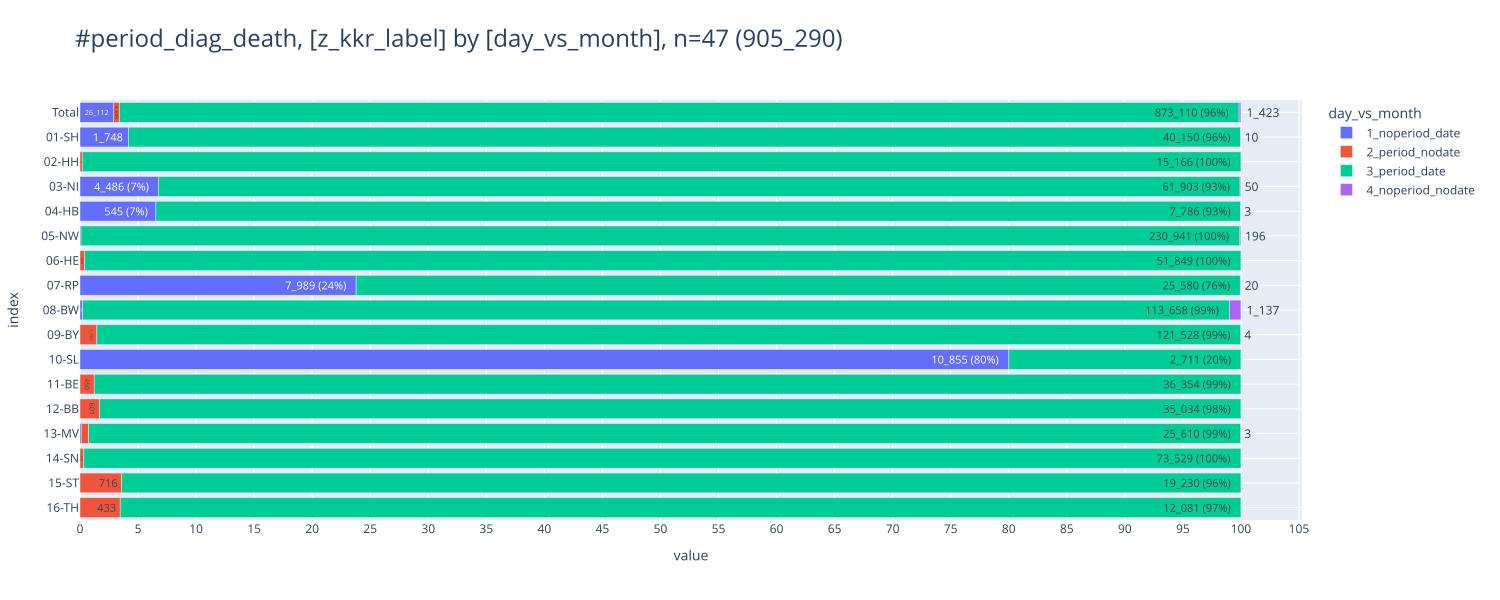

In [11]:
_=pls.plot_stacked_bars(db_diag_death.to_df().iloc[:,0:2], orientation='h', relative=True, height=600, show_total=True, caption="period_diag_death", show_pct_bar=True, width=1500)

### <a id='toc1_2_2_'></a>[Tagesabstand](#toc0_)
- **Werte für Gruppierung nach Tagesabstand**
  - `A_<0d` - Wert negativ
  - `B_0d` - Wert ist 0
  - `C_1-365d` - Wert ist 1-365 Tage
  - `D_1-10y` - Wert ist 1-10 Jahre
  - `E_>10y` - Wert ist > 10 Jahre

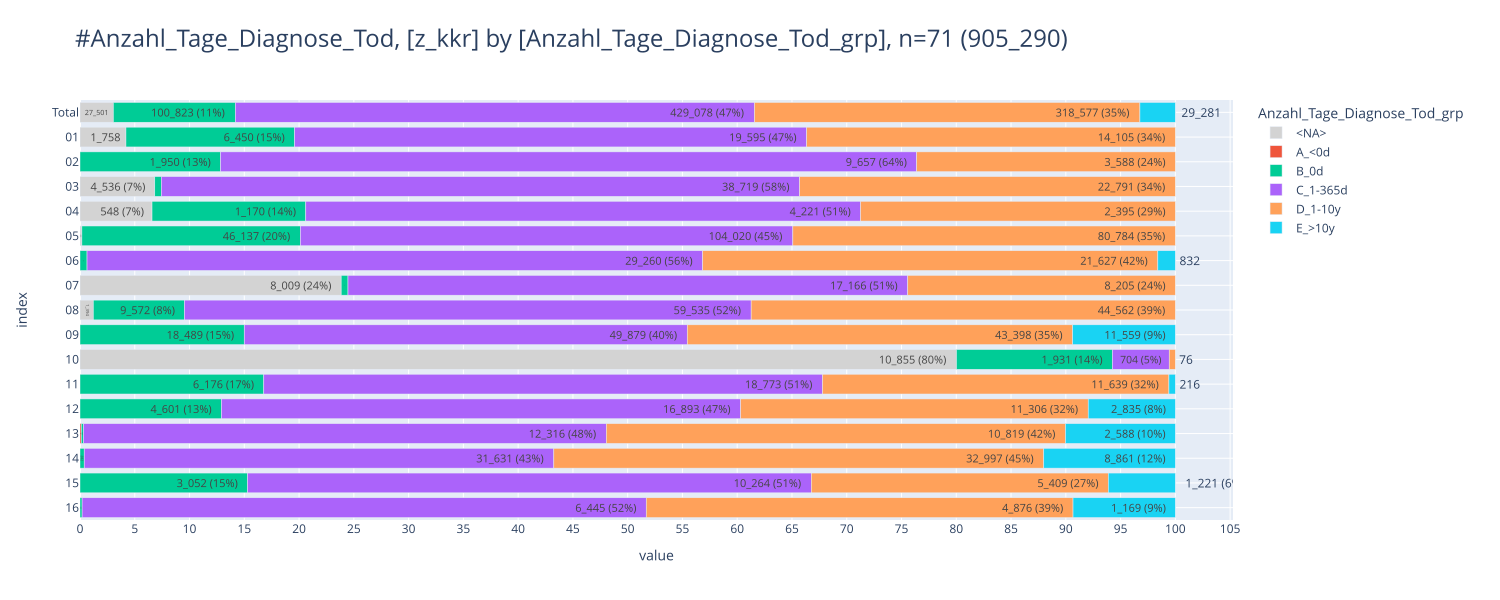

In [12]:
display_delay(
    con,
    delay="Anzahl_Tage_Diagnose_Tod",
    table="Tumor",
    join="join Patient on Tumor.z_pat_id = Patient.oBDS_RKIPatientId",
    where="where Verstorben='J'",
    yrs=10,
)

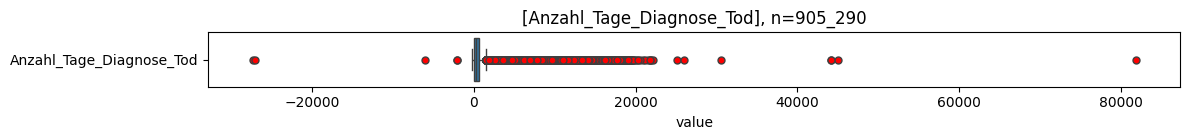

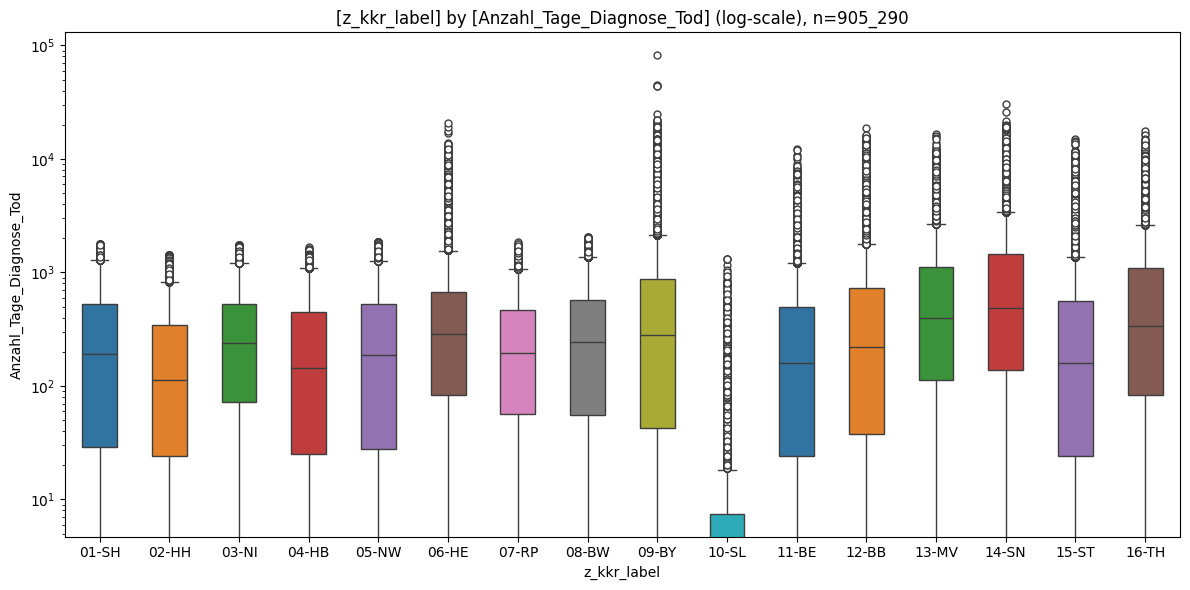


column (n = 905_290)     |    present    |   min   | lower |  q25  | median |  mean  |  q75   | upper |  max   |   std    |  cv 
-------------------------+---------------+---------+-------+-------+--------+--------+--------+-------+--------+----------+-----
Anzahl_Tage_Diagnose_Tod | 877_789 (96%) | -27_320 |  -212 | 48.00 | 237.00 | 599.56 | 632.00 | 1_508 | 81_801 | 1_219.97 | 2.03


item (n = 905_290) |  count  |   min   | lower |  q25   | median |   mean   |   q75    | upper |  max   |   std    |  cv 
-------------------+---------+---------+-------+--------+--------+----------+----------+-------+--------+----------+-----
01-SH              |  40_150 |       0 |     0 |  29.00 | 193.00 |   336.30 |   527.00 | 1_274 |  1_783 |   381.00 | 1.13
02-HH              |  15_195 |       0 |     0 |  24.00 | 113.00 |   232.92 |   346.00 |   829 |  1_424 |   283.40 | 1.22
03-NI              |  61_903 |       0 |     0 |  72.00 | 237.00 |   353.45 |   528.00 | 1_212 |  1_752 |   352.17 | 1.00


In [13]:
_df=con.sql("""--sql
    select z_kkr_label, Anzahl_Tage_Diagnose_Tod
    from Tumor join Patient on Tumor.z_pat_id = Patient.oBDS_RKIPatientId
    where Verstorben='J'
    order by z_kkr_label
""")
_=pls.plot_box_large(_df.project("Anzahl_Tage_Diagnose_Tod").to_df(), height=150, summary=False)
_=pls.plot_boxes_large(_df.to_df(), use_log=True)

### <a id='toc1_2_3_'></a>[Kategorien](#toc0_)
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_both_null` - Datumsabstand und Tagesangaben sind beide NULL ➡️ NULL
  - `2_both_invalid` - Datumsabstand und Tagesangaben sind ungültig ➡️ NULL
  - `3_deviation` - Abweichungen zwischen Datumsabstand / Tagesangaben sind erheblich ➡️ Tagesangabe
  - `4_both_0` - Datumsabstand und Tagesangaben sind beide 0 ➡️ 0
  - `51_day_ok` - Tagesangabe ist valide ➡️ Tagesangabe
  - `52_month_ok` - Datumsabstand ist valide ➡️ Datumsabstand

In [14]:
db_vital = con.sql(f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                tum.z_pat_id,
                z_kkr_label,
                Anzahl_Tage_Diagnose_Tod,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                Datum_Vitalstatus,
                Datum_Vitalstatus_Genauigkeit,
                Anzahl_Tage_Diagnose_Tod as period_day,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from Datum_Vitalstatus), extract(month from Datum_Vitalstatus), 15)
                )::int32 as period_month,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        where Verstorben = 'J'
    ),
    t2 as (
        select
                *,
                {case_categ_day_month( 'period_day', 'period_month', 'Datum_Vitalstatus_Genauigkeit', MAX_YEARS_VITAL)},
        from t1
    ),
    t3 as (
        select *,
                {case_categ_day_month_z('z_period_diag_death_day')}
        from t2
    ),
    t4 as (
        select  z_pat_id as pat_id,
                z_tum_id,
                z_kkr_label,
                z_period_diag_death_day,
                categ_day_month,
                row_number() over (partition by z_tum_id order by z_period_diag_death_day) as z_tum_order,
        from t3
    )
    select * from t3
    """)
# tbl.descr_db(db_vital, "vital")

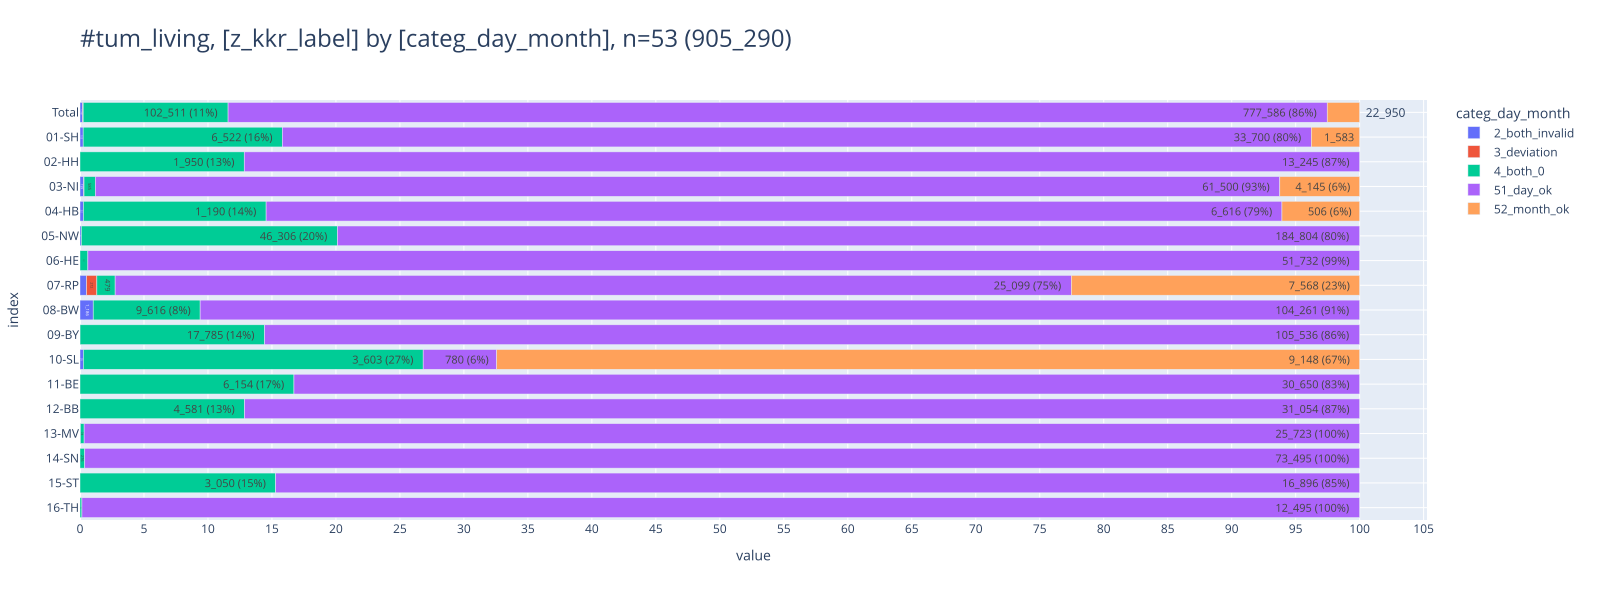

categ_day_month,2_both_invalid,3_deviation,4_both_0,51_day_ok,52_month_ok,Total
z_kkr_label,,,,,,
01-SH,103 (0.0%),0,6_522 (0.7%),33_700 (3.7%),1_583 (0.2%),41_908 (4.6%)
02-HH,0,0,1_950 (0.2%),13_245 (1.5%),0,15_195 (1.7%)
03-NI,199 (0.0%),10 (0.0%),585 (0.1%),61_500 (6.8%),4_145 (0.5%),66_439 (7.3%)
04-HB,22 (0.0%),0,1_190 (0.1%),6_616 (0.7%),506 (0.1%),8_334 (0.9%)
05-NW,231 (0.0%),0,46_306 (5.1%),184_804 (20.4%),0,231_341 (25.6%)
06-HE,0,0,321 (0.0%),51_732 (5.7%),0,52_053 (5.7%)
07-RP,171 (0.0%),272 (0.0%),479 (0.1%),25_099 (2.8%),7_568 (0.8%),33_589 (3.7%)
08-BW,1_186 (0.1%),0,9_616 (1.1%),104_261 (11.5%),0,115_063 (12.7%)
09-BY,5 (0.0%),0,17_785 (2.0%),105_536 (11.7%),0,123_326 (13.6%)


In [15]:
pls.plot_stacked_bars(
    db_vital.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_living",
    height=600,
    width=1600,
)
tbl.pivot_df(db_vital.project("z_kkr_label,categ_day_month").to_df())

In [16]:
if os.environ.get("DEBUG") == "1":
    db_vital_filter = db_vital.filter("left(categ_day_month,1) = '2'").order("deviation desc").project("* exclude (z_pat_id,Anzahl_Tage_Diagnose_Tod)")
    display(db_vital_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

## <a id='toc1_3_'></a>[Diagnose -> OP](#toc0_)
- Filter: keiner
- gezählt sind OP

### <a id='toc1_3_1_'></a>[Tagesabstand vs Datumsangaben](#toc0_)
- **Werte für Variablen zur Verteilung**
  - `1_noperiod_date` - kein Tagesabstand, aber Datumsangaben
  - `2_period_nodate` - Tagesabstand, aber keine Datumsangaben
  - `3_period_date` - Tagesabstand und Datumsangaben
  - `4_noperiod_nodate` - kein Tagesabstand, keine Datumsangaben

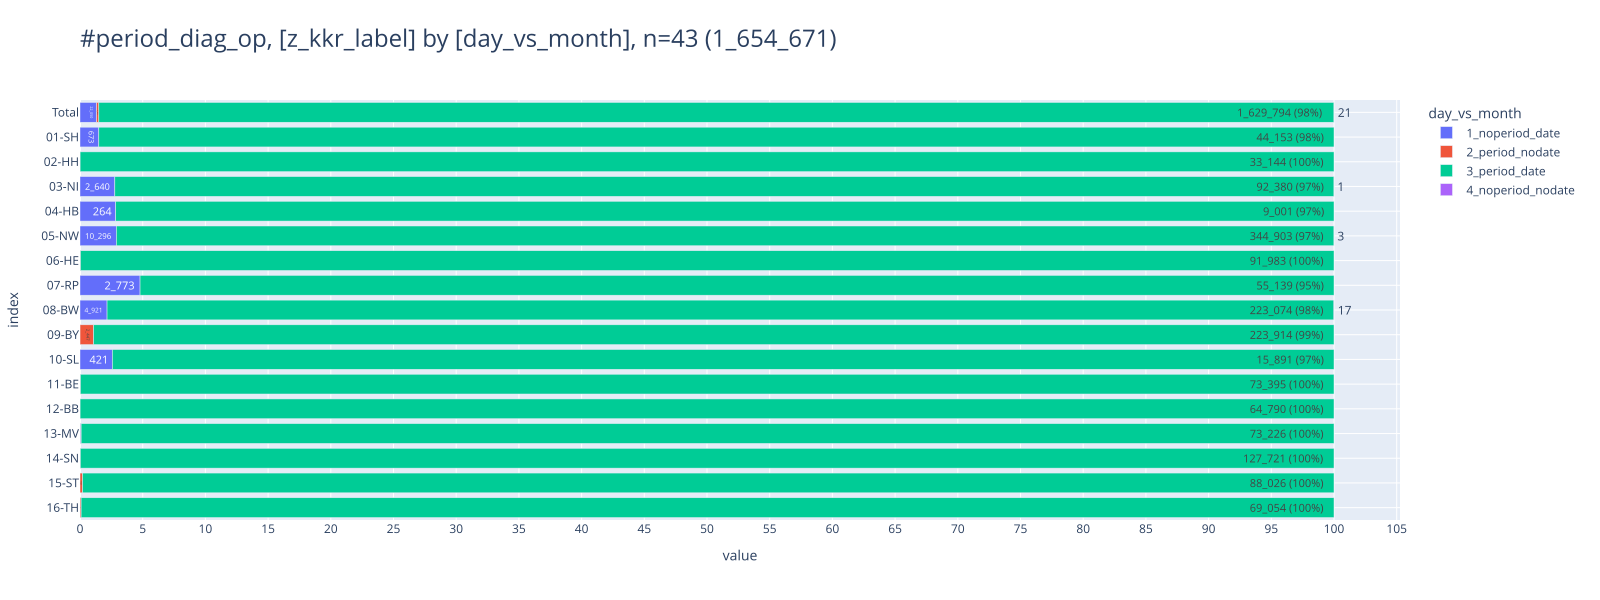

In [17]:
_=pls.plot_stacked_bars(db_diag_op.to_df().iloc[:,0:2], orientation='h', relative=True, height=600, show_total=True, caption="period_diag_op", show_pct_bar=True, width=1600)

### <a id='toc1_3_2_'></a>[Tagesabstand](#toc0_)
- **Werte für Gruppierung nach Tagesabstand**
  - `A_<0d` - Wert negativ
  - `B_0d` - Wert ist 0
  - `C_1-365d` - Wert ist 1-365 Tage
  - `D_1-10y` - Wert ist 1-10 Jahre
  - `E_>10y` - Wert ist > 10 Jahre

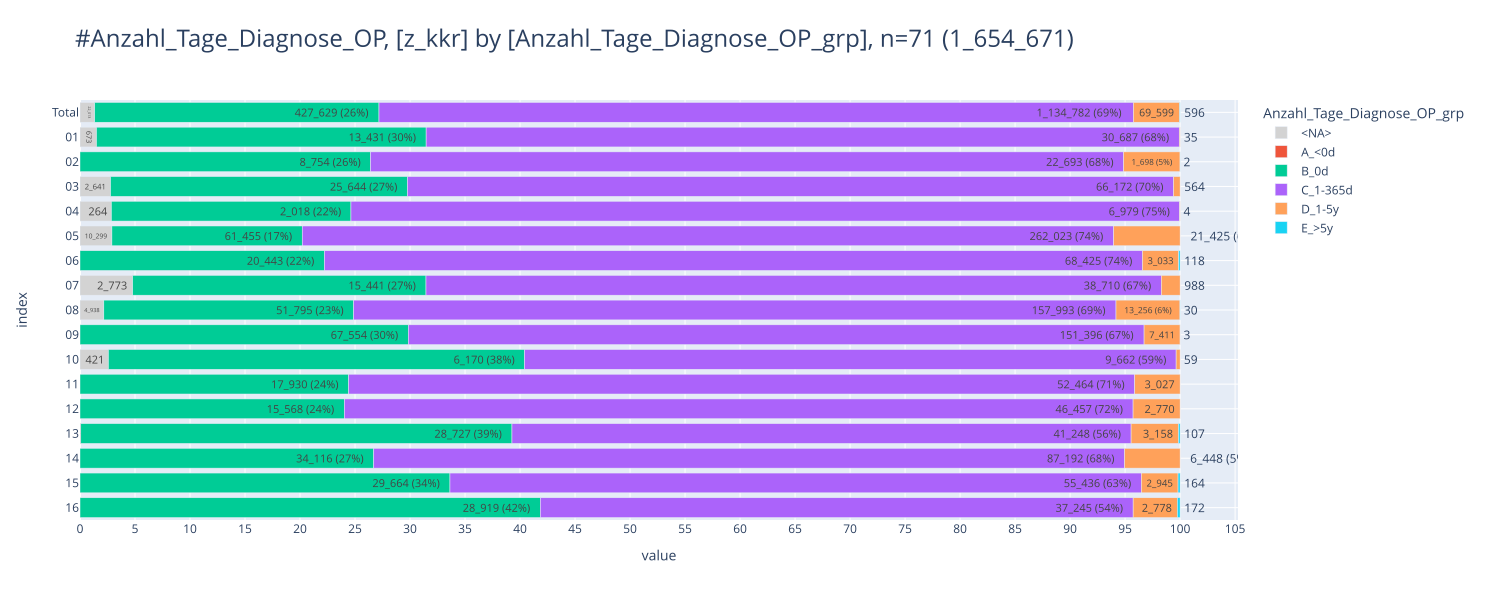

In [18]:
display_delay(con, delay="Anzahl_Tage_Diagnose_OP", table="OP")

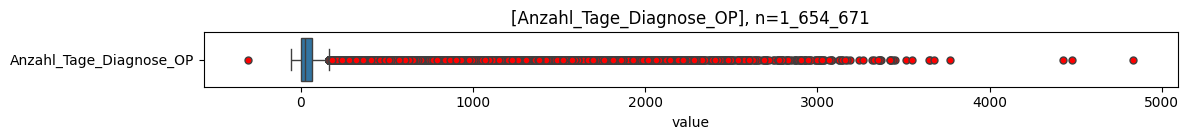

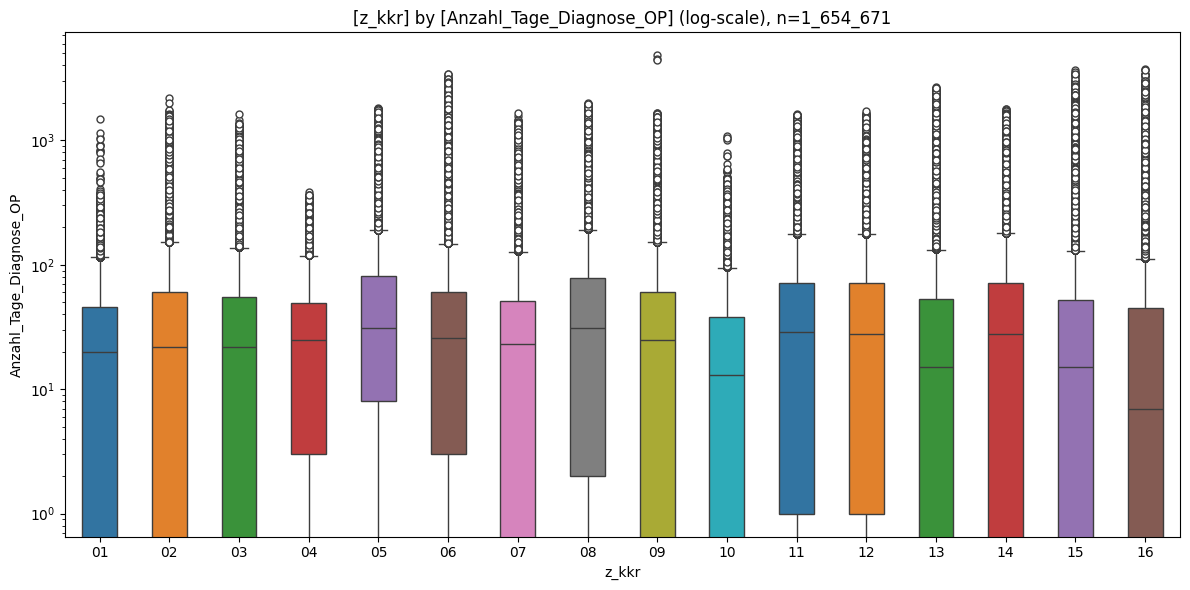


column (n = 1_654_671)  |     present     | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std   |  cv 
------------------------+-----------------+------+-------+------+--------+-------+-------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_OP | 1_632_658 (98%) | -304 |   -56 | 0.00 |  26.00 | 74.88 | 65.00 |   162 | 4_835 | 163.28 | 2.18


item (n = 1_654_671) |  count  | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std   |  cv 
---------------------+---------+------+-------+------+--------+-------+-------+-------+-------+--------+-----
01                   |  44_153 |    0 |     0 | 0.00 |  20.00 | 39.21 | 46.00 |   115 | 1_498 |  59.89 | 1.53
02                   |  33_147 |    0 |     0 | 0.00 |  22.00 | 77.09 | 61.00 |   152 | 2_204 | 169.17 | 2.19
03                   |  92_380 |    0 |     0 | 0.00 |  22.00 | 47.08 | 55.00 |   137 | 1_635 |  76.37 | 1.62
04                   |   9_001 |    0 |     0 | 3.00 |  25.00 | 42.04 | 49.00 |   11

In [19]:
_df=con.sql("""--sql
    select lpad(z_kkr::text,2,'0') as z_kkr, Anzahl_Tage_Diagnose_OP
    from OP
    order by z_kkr
""")
_=pls.plot_box_large(_df.project("Anzahl_Tage_Diagnose_OP").to_df(), height=150, summary=False)
_=pls.plot_boxes_large(_df.to_df(), use_log=True)

### <a id='toc1_3_3_'></a>[Kategorien](#toc0_)
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_both_null` - Datumsabstand und Tagesangaben sind beide NULL ➡️ NULL
  - `2_both_invalid` - Datumsabstand und Tagesangaben sind ungültig ➡️ NULL
  - `3_deviation` - Abweichungen zwischen Datumsabstand / Tagesangaben sind erheblich ➡️ Tagesangabe
  - `4_both_0` - Datumsabstand und Tagesangaben sind beide 0 ➡️ 0
  - `51_day_ok` - Tagesangabe ist valide ➡️ Tagesangabe
  - `52_month_ok` - Datumsabstand ist valide ➡️ Datumsabstand

In [20]:
sql_op = (f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                z_kkr_label,
                OPId,
                Anzahl_Tage_Diagnose_OP,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                Datum_OP,
                Datum_OP_Genauigkeit,
                Anzahl_Tage_Diagnose_OP as period_day,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from Datum_OP), extract(month from Datum_OP), 15)
                )::int32 as period_month,
        from Tumor tum
        join OP op on tum.z_tum_id = op.z_tum_id
    ),
    t2 as (
        select
                *,
                {case_categ_day_month('period_day', 'period_month', 'Datum_OP_Genauigkeit', MAX_YEARS_TREAT)},
        from t1
    ),
    t3 as (
        select  *,
                {case_categ_day_month_z('z_period_diag_op_day')},
        from t2
    ),
    t4 as (
        select  OPId as op_id,
                z_tum_id,
                z_kkr_label,
                z_period_diag_op_day,
                categ_day_month,
                row_number() over (partition by z_tum_id order by z_period_diag_op_day) as z_op_order,
        from t3
    )
    select * from t3
    """)
# print(sql_op)
db_op = con.sql(sql_op)
# tbl.descr_db(db_op, "op")

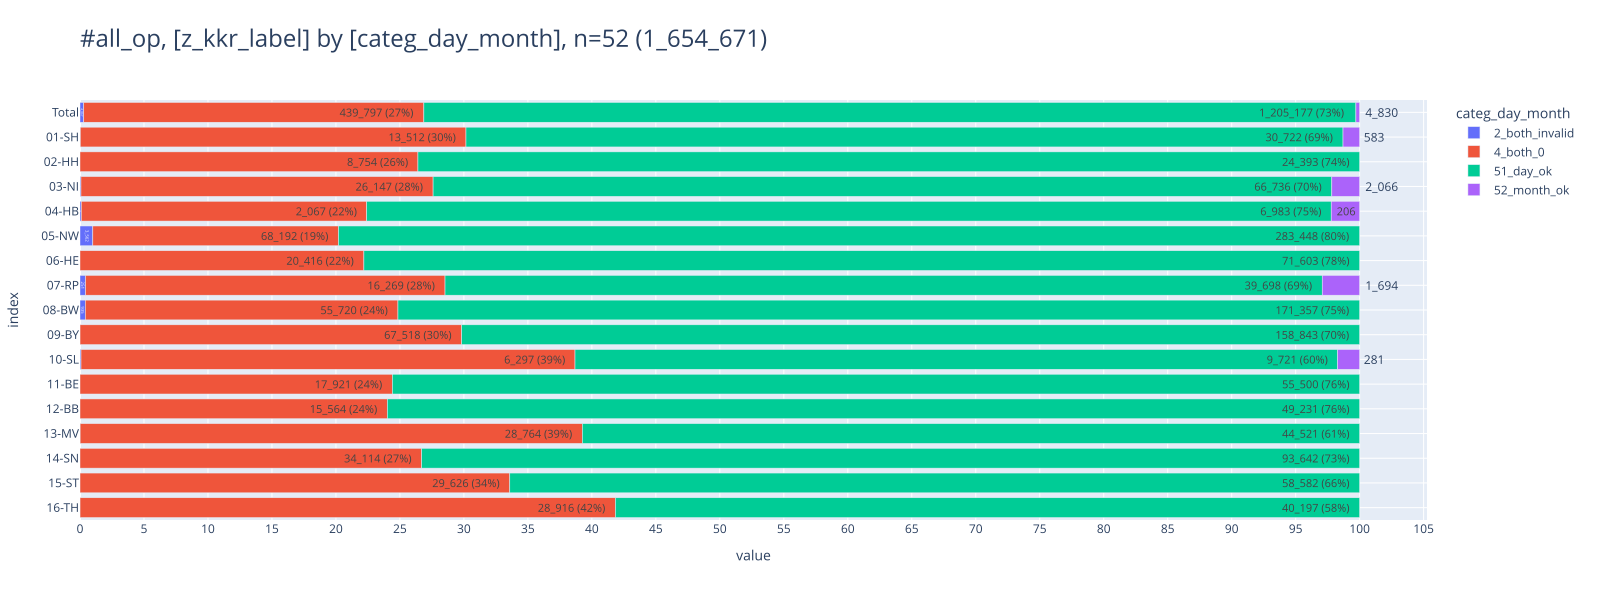

categ_day_month,2_both_invalid,4_both_0,51_day_ok,52_month_ok,Total
z_kkr_label,,,,,
01-SH,9 (0.0%),13_512 (0.8%),30_722 (1.9%),583 (0.0%),44_826 (2.7%)
02-HH,0,8_754 (0.5%),24_393 (1.5%),0,33_147 (2.0%)
03-NI,72 (0.0%),26_147 (1.6%),66_736 (4.0%),2_066 (0.1%),95_021 (5.7%)
04-HB,9 (0.0%),2_067 (0.1%),6_983 (0.4%),206 (0.0%),9_265 (0.6%)
05-NW,3_562 (0.2%),68_192 (4.1%),283_448 (17.1%),0,355_202 (21.5%)
06-HE,0,20_416 (1.2%),71_603 (4.3%),0,92_019 (5.6%)
07-RP,251 (0.0%),16_269 (1.0%),39_698 (2.4%),1_694 (0.1%),57_912 (3.5%)
08-BW,935 (0.1%),55_720 (3.4%),171_357 (10.4%),0,228_012 (13.8%)
09-BY,6 (0.0%),67_518 (4.1%),158_843 (9.6%),0,226_367 (13.7%)


In [21]:
pls.plot_stacked_bars(
    db_op.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="all_op",
    height=600,
    width=1600,
)
tbl.pivot_df(db_op.project("z_kkr_label,categ_day_month").to_df())

In [22]:
if os.environ.get("DEBUG") == "1":
    db_op_filter = db_op.filter("left(categ_day_month,1) = '2'").project("* exclude (OPId,Anzahl_Tage_Diagnose_OP )").order("deviation desc")
    # db_op_filter = db_op.filter("op_id = '52551497-4a3e-4925-9ce1-ff19eef4f2e4'")
    display(db_op_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

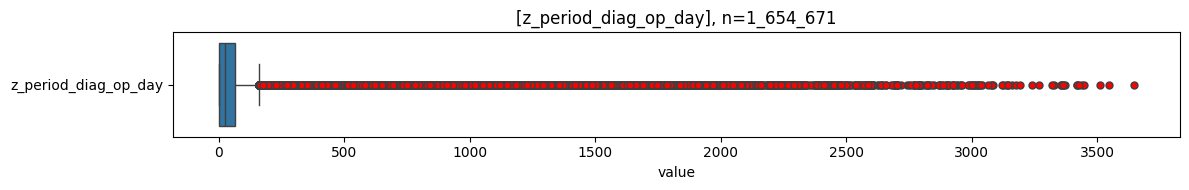


column (n = 1_654_671) |     present     | min | lower |  q25  | median |  mean  |  q75   | upper |  max  |   std   |  cv  
-----------------------+-----------------+-----+-------+-------+--------+--------+--------+-------+-------+---------+------
z_period_diag_op_day   | 1_649_804 (99%) |   0 |     0 | 0.000 | 26.000 | 74.369 | 64.000 |   160 | 3_648 | 162.508 | 2.185



In [23]:
pls.plot_box_large(db_op.to_df().z_period_diag_op_day)

## <a id='toc1_4_'></a>[Diagnose -> SYST](#toc0_)
- Filter: keiner
- gezählt sind SYST

### <a id='toc1_4_1_'></a>[Tagesabstand vs Datumsangaben](#toc0_)
- **Werte für Variablen zur Verteilung**
  - `1_noperiod_date` - kein Tagesabstand, aber Datumsangaben
  - `2_period_nodate` - Tagesabstand, aber keine Datumsangaben
  - `3_period_date` - Tagesabstand und Datumsangaben
  - `4_noperiod_nodate` - kein Tagesabstand, keine Datumsangaben

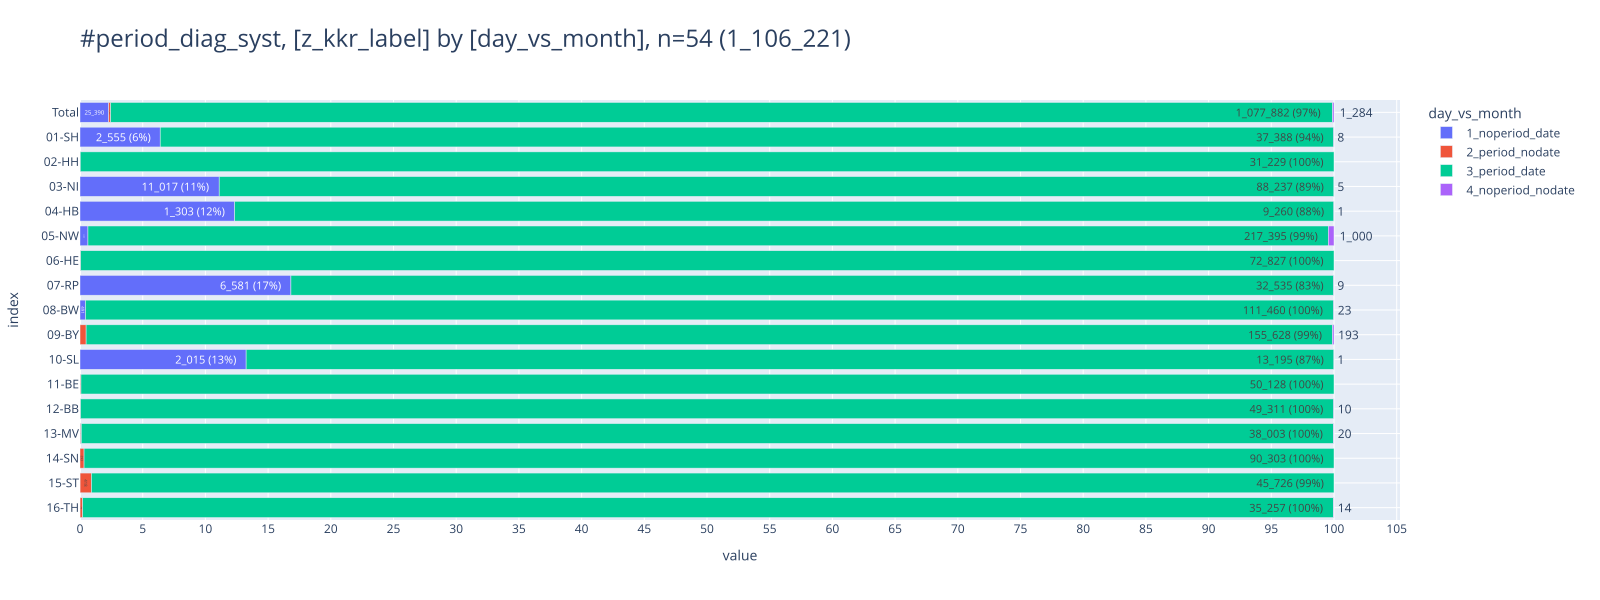

In [24]:
_=pls.plot_stacked_bars(db_diag_syst.to_df().iloc[:,0:2], orientation='h', relative=True, height=600, show_total=True, caption="period_diag_syst", show_pct_bar=True, width=1600)

### <a id='toc1_4_2_'></a>[Tagesabstand](#toc0_)
- **Werte für Gruppierung nach Tagesabstand**
  - `A_<0d` - Wert negativ
  - `B_0d` - Wert ist 0
  - `C_1-365d` - Wert ist 1-365 Tage
  - `D_1-10y` - Wert ist 1-10 Jahre
  - `E_>10y` - Wert ist > 10 Jahre

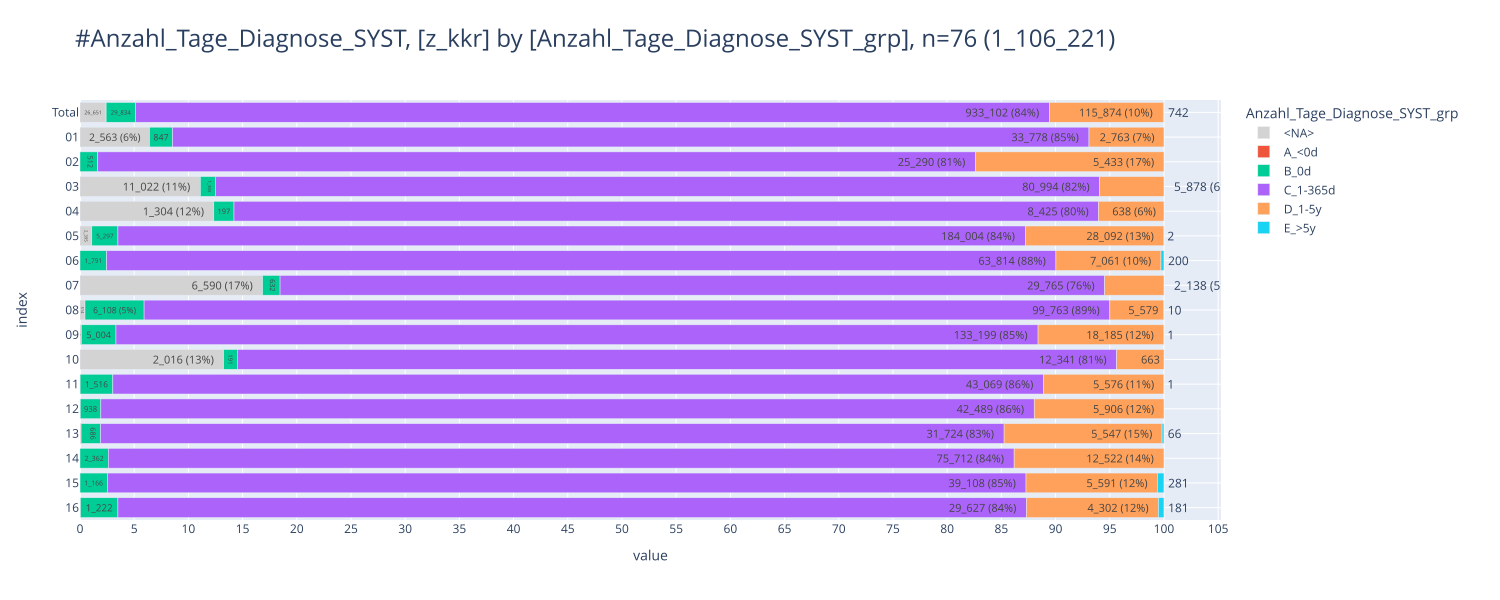

In [25]:
display_delay(con, "Anzahl_Tage_Diagnose_SYST", "SYST")

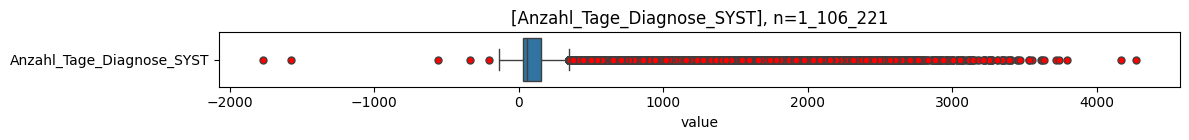

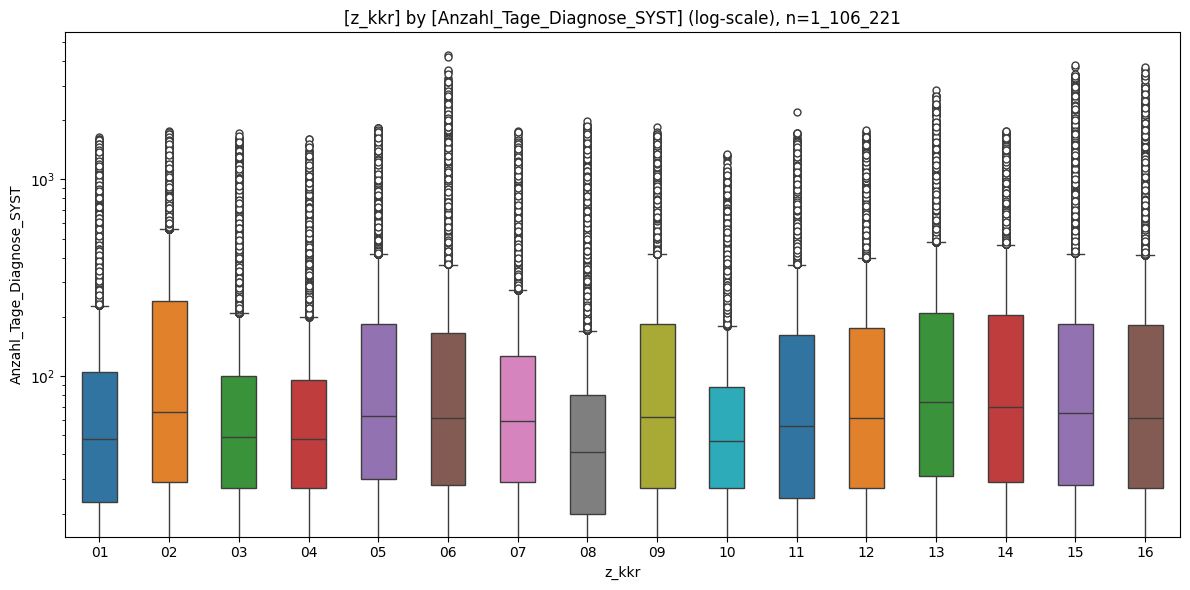


column (n = 1_106_221)    |     present     |  min   | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
--------------------------+-----------------+--------+-------+-------+--------+--------+--------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_SYST | 1_079_570 (97%) | -1_772 |  -139 | 27.00 |  57.00 | 144.63 | 154.00 |   344 | 4_275 | 227.24 | 1.57


item (n = 1_106_221) |  count  |  min   | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
---------------------+---------+--------+-------+-------+--------+--------+--------+-------+-------+--------+-----
01                   |  37_388 |      0 |     0 | 23.00 |  48.00 | 111.69 | 105.00 |   228 | 1_637 | 184.84 | 1.65
02                   |  31_235 |      0 |     0 | 29.00 |  66.00 | 193.25 | 241.00 |   559 | 1_758 | 272.75 | 1.41
03                   |  88_237 |      0 |     0 | 27.00 |  49.00 | 107.14 | 100.00 |   209 | 1_724 | 173.22 | 1.62
04                   |   9_260 |      

In [26]:
_df=con.sql("""--sql
    select lpad(z_kkr::text,2,'0') as z_kkr, Anzahl_Tage_Diagnose_SYST
    from SYST
    order by z_kkr
""")
_=pls.plot_box_large(_df.project("Anzahl_Tage_Diagnose_SYST").to_df(), height=150, summary=False)
_=pls.plot_boxes_large(_df.to_df(), use_log=True)

### <a id='toc1_4_3_'></a>[Kategorien](#toc0_)
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_both_null` - Datumsabstand und Tagesangaben sind beide NULL ➡️ NULL
  - `2_both_invalid` - Datumsabstand und Tagesangaben sind ungültig ➡️ NULL
  - `3_deviation` - Abweichungen zwischen Datumsabstand / Tagesangaben sind erheblich ➡️ Tagesangabe
  - `4_both_0` - Datumsabstand und Tagesangaben sind beide 0 ➡️ 0
  - `51_day_ok` - Tagesangabe ist valide ➡️ Tagesangabe
  - `52_month_ok` - Datumsabstand ist valide ➡️ Datumsabstand

In [27]:
db_syst = con.sql(f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                z_kkr_label,
                SYSTId,
                Anzahl_Tage_Diagnose_SYST,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                Datum_Beginn_SYST,
                Datum_Beginn_SYST_Genauigkeit,
                Anzahl_Tage_Diagnose_SYST as period_day,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from Datum_Beginn_SYST), extract(month from Datum_Beginn_SYST), 15)
                )::int32 as period_month,
        from SYST sy
        join Tumor tum on tum.z_tum_id = sy.z_tum_id
    ),
    t2 as (
        select
                *,
                {case_categ_day_month( 'period_day', 'period_month', 'Datum_Beginn_SYST_Genauigkeit', MAX_YEARS_TREAT)}
        from t1
    ),
    t3 as (
        select  *,
                {case_categ_day_month_z('z_period_diag_syst_day')},
        from t2
    ),
    t4 as (
        select  SYSTId as syst_id,
                z_tum_id,
                z_kkr_label,
                z_period_diag_syst_day,
                categ_day_month,
                row_number() over (partition by z_tum_id order by z_period_diag_syst_day) as z_syst_order,
        from t3
    )
    select * from t3
    """)
# tbl.descr_db(db_syst, "syst")

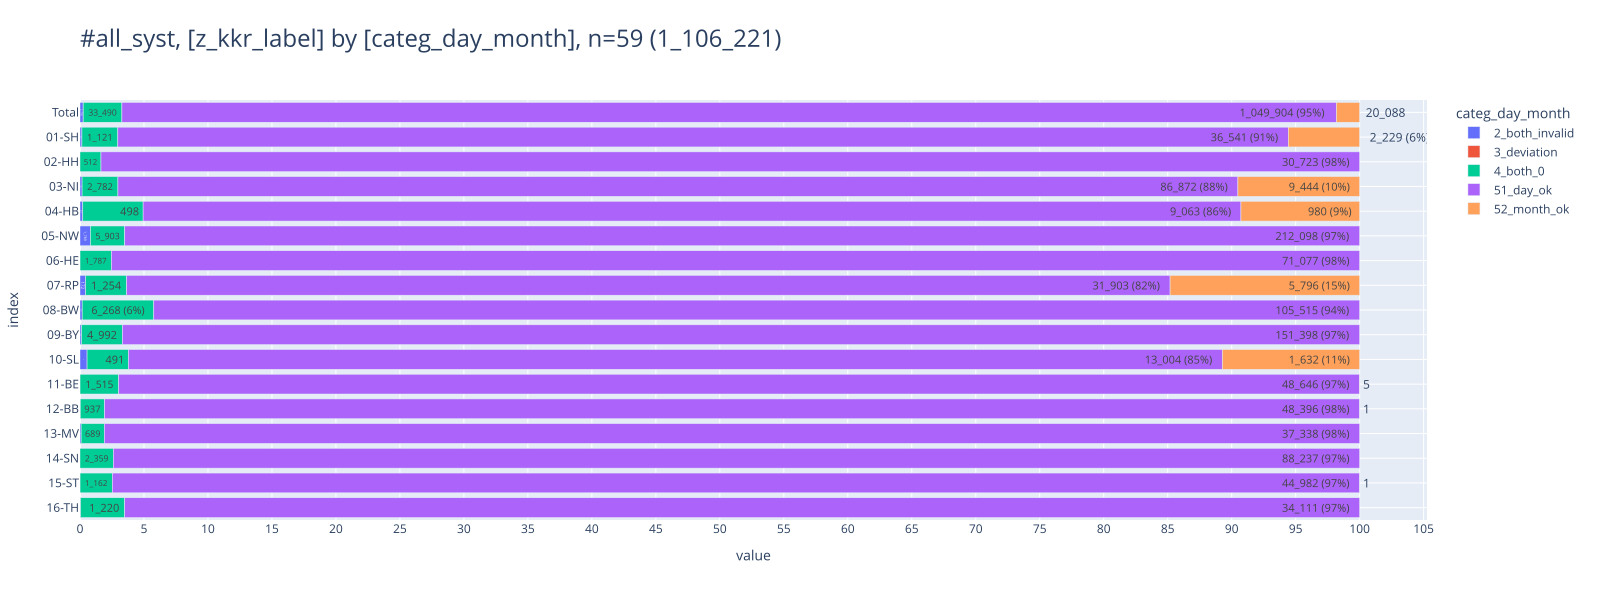

categ_day_month,2_both_invalid,3_deviation,4_both_0,51_day_ok,52_month_ok,Total
z_kkr_label,,,,,,
01-SH,60 (0.0%),0,1_121 (0.1%),36_541 (3.3%),2_229 (0.2%),39_951 (3.6%)
02-HH,0,0,512 (0.0%),30_723 (2.8%),0,31_235 (2.8%)
03-NI,161 (0.0%),0,2_782 (0.3%),86_872 (7.9%),9_444 (0.9%),99_259 (9.0%)
04-HB,23 (0.0%),0,498 (0.0%),9_063 (0.8%),980 (0.1%),10_564 (1.0%)
05-NW,1_789 (0.2%),0,5_903 (0.5%),212_098 (19.2%),0,219_790 (19.9%)
06-HE,2 (0.0%),0,1_787 (0.2%),71_077 (6.4%),0,72_866 (6.6%)
07-RP,172 (0.0%),0,1_254 (0.1%),31_903 (2.9%),5_796 (0.5%),39_125 (3.5%)
08-BW,191 (0.0%),0,6_268 (0.6%),105_515 (9.5%),0,111_974 (10.1%)
09-BY,194 (0.0%),0,4_992 (0.5%),151_398 (13.7%),0,156_584 (14.2%)


In [28]:
pls.plot_stacked_bars(
    db_syst.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="all_syst",
    height=600,
    width=1600,
)
tbl.pivot_df(db_syst.project("z_kkr_label,categ_day_month").to_df())

In [29]:
if os.environ.get("DEBUG") == "1":
    db_sy_filter = db_syst.filter("left(categ_day_month,1) = '3'").order("deviation desc").project("* exclude (SYSTId,Anzahl_Tage_Diagnose_SYST )")
    # db_op_filter = db_op.filter("op_id = '52551497-4a3e-4925-9ce1-ff19eef4f2e4'")
    display(db_sy_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

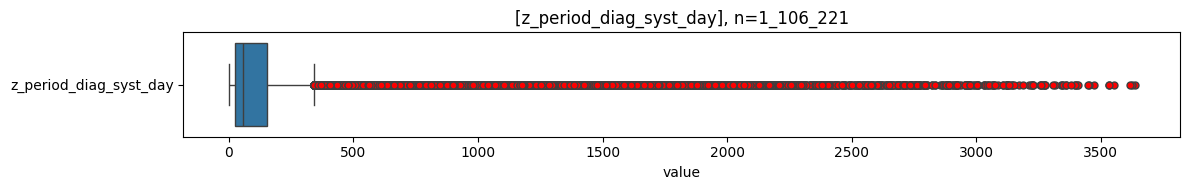


column (n = 1_106_221) |     present     | min | lower |  q25   | median |  mean   |   q75   | upper |  max  |   std   |  cv  
-----------------------+-----------------+-----+-------+--------+--------+---------+---------+-------+-------+---------+------
z_period_diag_syst_day | 1_103_483 (99%) |   0 |     0 | 27.000 | 57.000 | 143.982 | 153.000 |   342 | 3_636 | 226.106 | 1.570



In [30]:
pls.plot_box_large(db_syst.to_df().z_period_diag_syst_day)

## <a id='toc1_5_'></a>[Diagnose -> Bestrahlung](#toc0_)
- Filter: keiner
- gezählt sind Teilbestrahlungen

### <a id='toc1_5_1_'></a>[Tagesabstand vs Datumsangaben](#toc0_)
- **Werte für Variablen zur Verteilung**
  - `1_noperiod_date` - kein Tagesabstand, aber Datumsangaben
  - `2_period_nodate` - Tagesabstand, aber keine Datumsangaben
  - `3_period_date` - Tagesabstand und Datumsangaben
  - `4_noperiod_nodate` - kein Tagesabstand, keine Datumsangaben

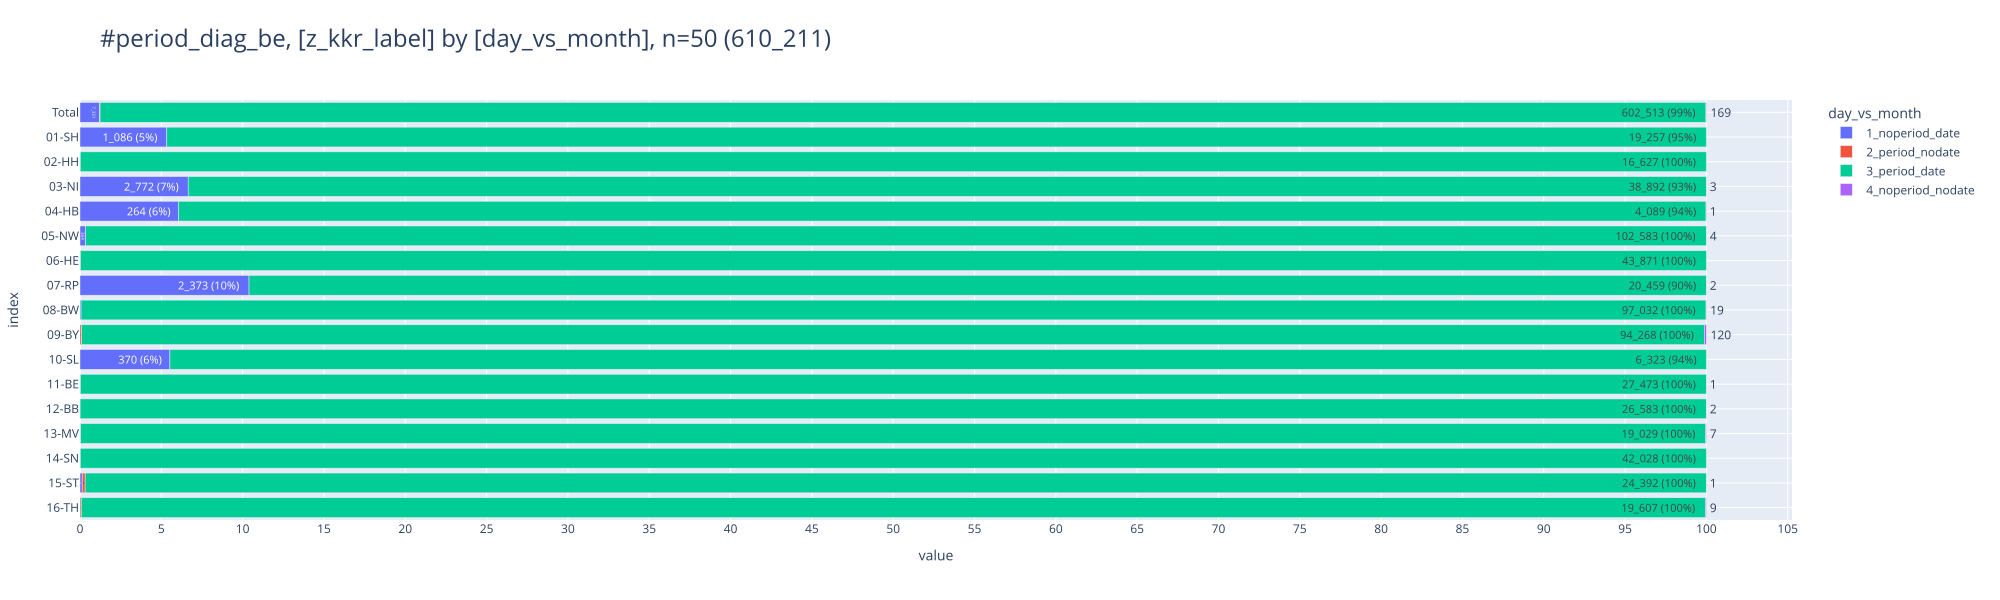

In [31]:
_=pls.plot_stacked_bars(db_diag_be.to_df().iloc[:,0:2], orientation='h', relative=True, height=600, show_total=True, caption="period_diag_be", show_pct_bar=True)

### <a id='toc1_5_2_'></a>[Tagesabstand](#toc0_)
- **Werte für Gruppierung nach Tagesabstand**
  - `A_<0d` - Wert negativ
  - `B_0d` - Wert ist 0
  - `C_1-365d` - Wert ist 1-365 Tage
  - `D_1-10y` - Wert ist 1-10 Jahre
  - `E_>10y` - Wert ist > 10 Jahre

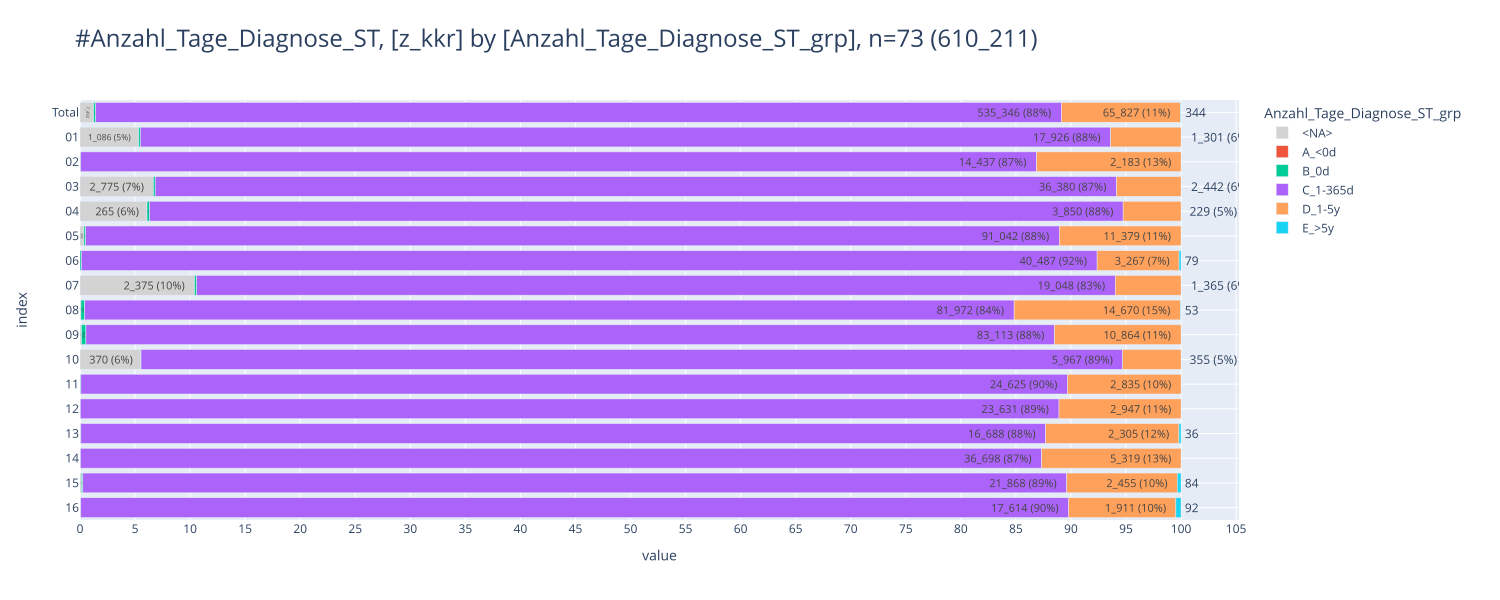

In [32]:
display_delay(con, "Anzahl_Tage_Diagnose_ST", "Bestrahlung")

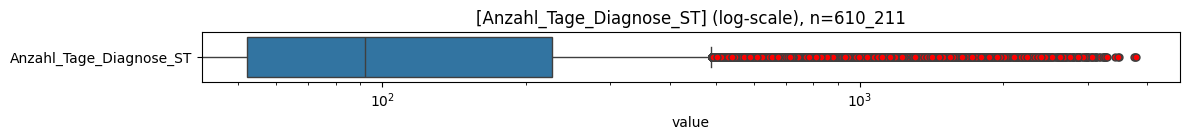

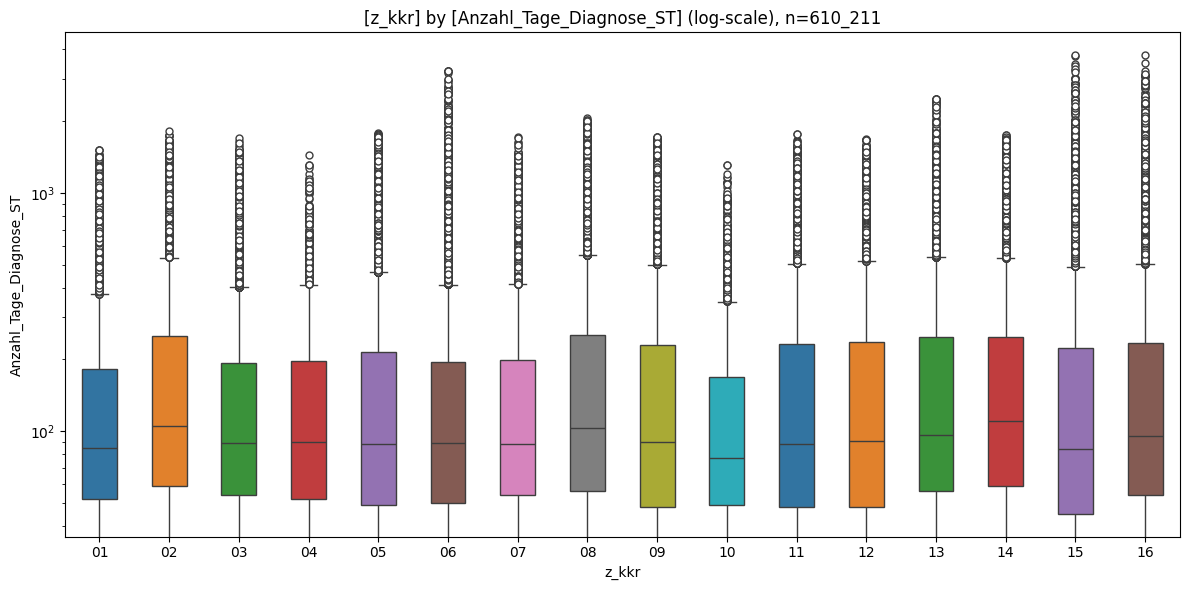


column (n = 610_211)    |    present    |   min    | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
------------------------+---------------+----------+-------+-------+--------+--------+--------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_ST | 602_719 (98%) | -657_402 |   -27 | 52.00 |  92.00 | 176.62 | 227.00 |   489 | 3_782 | 877.04 | 4.97


item (n = 610_211) |  count  |   min    | lower |  q25  | median |  mean  |  q75   | upper |  max  |   std    |  cv  
-------------------+---------+----------+-------+-------+--------+--------+--------+-------+-------+----------+------
01                 |  19_257 |        0 |     0 | 52.00 |  85.00 | 144.28 | 182.00 |   377 | 1_519 |   168.12 |  1.17
02                 |  16_630 |        0 |     0 | 59.00 | 105.00 | 201.91 | 250.00 |   535 | 1_814 |   246.49 |  1.22
03                 |  38_892 |        0 |     0 | 54.00 |  89.00 | 145.43 | 193.00 |   401 | 1_700 |   164.06 |  1.13
04                 |   4_089 

In [47]:
_df=con.sql("""--sql
select lpad(z_kkr::text,2,'0') as z_kkr, Anzahl_Tage_Diagnose_ST
from Bestrahlung
--where Anzahl_Tage_Diagnose_ST > -657402
""")

_=pls.plot_box_large(_df.project("Anzahl_Tage_Diagnose_ST").to_df(), height=150, summary=False, use_log=True)
_=pls.plot_boxes_large(_df.to_df(), use_log=True)

### <a id='toc1_5_3_'></a>[Kategorien](#toc0_)
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_both_null` - Datumsabstand und Tagesangaben sind beide NULL ➡️ NULL
  - `2_both_invalid` - Datumsabstand und Tagesangaben sind ungültig ➡️ NULL
  - `3_deviation` - Abweichungen zwischen Datumsabstand / Tagesangaben sind erheblich ➡️ Tagesangabe
  - `4_both_0` - Datumsabstand und Tagesangaben sind beide 0 ➡️ 0
  - `51_day_ok` - Tagesangabe ist valide ➡️ Tagesangabe
  - `52_month_ok` - Datumsabstand ist valide ➡️ Datumsabstand

In [34]:
db_be = con.sql(f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                z_kkr_label,
                BestrahlungId,
                Anzahl_Tage_Diagnose_ST,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                Datum_Beginn_Bestrahlung,
                Datum_Beginn_Bestrahlung_Genauigkeit,
                Anzahl_Tage_Diagnose_ST as period_day,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from Datum_Beginn_Bestrahlung), extract(month from Datum_Beginn_Bestrahlung), 15)
                )::int32 as period_month,
        from Bestrahlung be
        join Tumor tum on tum.z_tum_id = be.z_tum_id
    ),
    t2 as (
        select  *,
                {case_categ_day_month( 'period_day', 'period_month', 'Datum_Beginn_Bestrahlung_Genauigkeit', MAX_YEARS_TREAT)}
        from t1
    ),
    t3 as (
        select  *,
                {case_categ_day_month_z('z_period_diag_be_day')},
        from t2
    ),
    t4 as (
        select  BestrahlungId as be_id,
                z_tum_id,
                z_kkr_label,
                z_period_diag_be_day,
                categ_day_month,
                row_number() over (partition by z_tum_id order by z_period_diag_be_day) as z_be_order,
        from t3
    )
    select * from t3
    """)
# tbl.descr_db(db_be, "be")

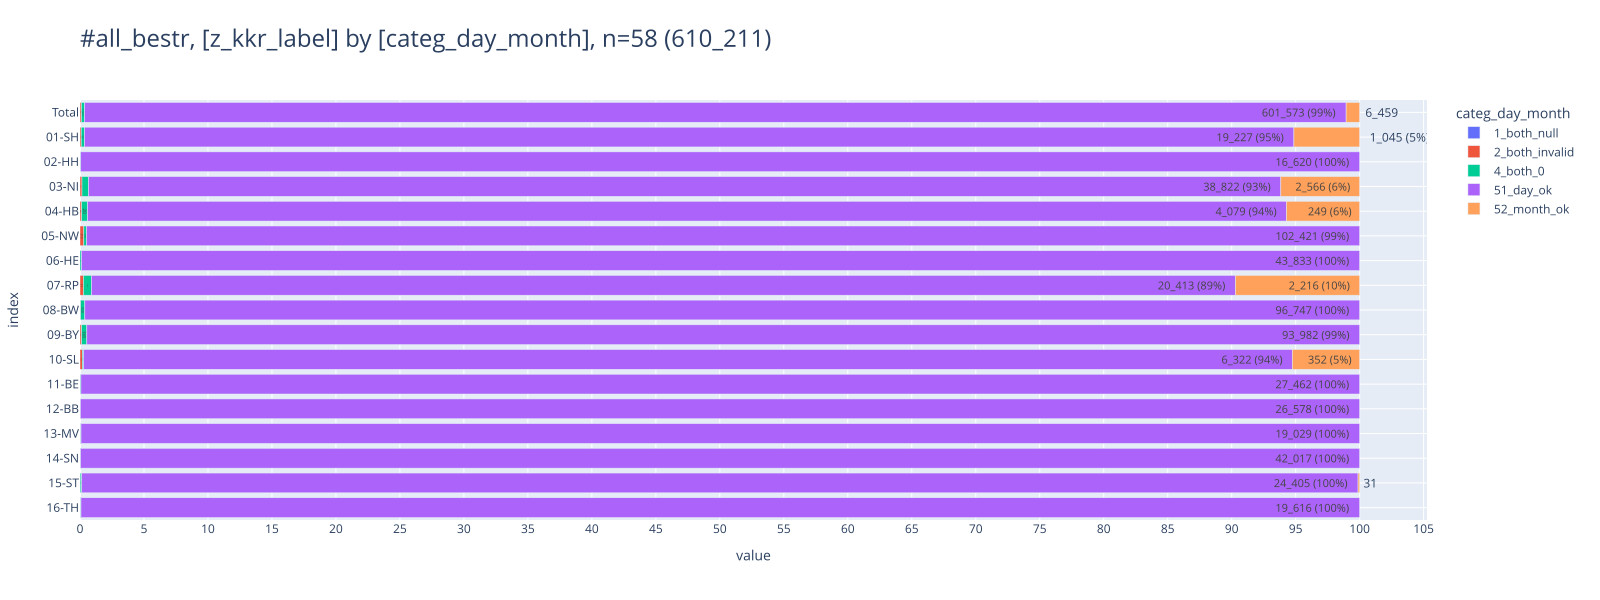

categ_day_month,1_both_null,2_both_invalid,4_both_0,51_day_ok,52_month_ok,Total
z_kkr_label,,,,,,
01-SH,0,19 (0.0%),52 (0.0%),19_227 (3.2%),1_045 (0.2%),20_343 (3.3%)
02-HH,0,0,10 (0.0%),16_620 (2.7%),0,16_630 (2.7%)
03-NI,0,65 (0.0%),214 (0.0%),38_822 (6.4%),2_566 (0.4%),41_667 (6.8%)
04-HB,0,6 (0.0%),20 (0.0%),4_079 (0.7%),249 (0.0%),4_354 (0.7%)
05-NW,0,310 (0.1%),220 (0.0%),102_421 (16.8%),0,102_951 (16.9%)
06-HE,0,0,53 (0.0%),43_833 (7.2%),0,43_886 (7.2%)
07-RP,0,61 (0.0%),144 (0.0%),20_413 (3.3%),2_216 (0.4%),22_834 (3.7%)
08-BW,0,48 (0.0%),320 (0.1%),96_747 (15.9%),0,97_115 (15.9%)
09-BY,0,120 (0.0%),385 (0.1%),93_982 (15.4%),0,94_487 (15.5%)


In [35]:
pls.plot_stacked_bars(
    db_be.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="all_bestr",
    height=600,
    width=1600,
)
tbl.pivot_df(db_be.project("z_kkr_label,categ_day_month").to_df())

In [36]:
if os.environ.get("DEBUG") == "1":
    db_be_filter = db_be.filter("left(categ_day_month,1) = '2'").order("deviation desc").project("* exclude (BestrahlungId,Anzahl_Tage_Diagnose_ST)")
    # db_op_filter = db_op.filter("op_id = '52551497-4a3e-4925-9ce1-ff19eef4f2e4'")
    display(db_be_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

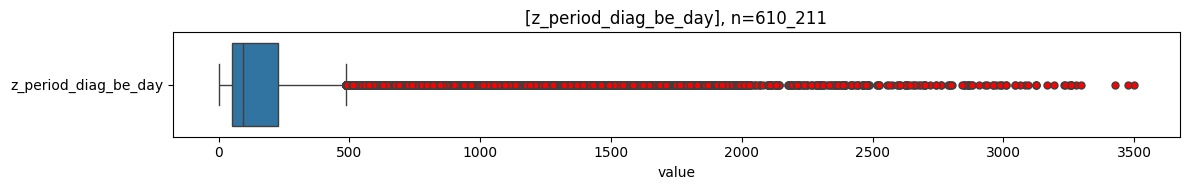


column (n = 610_211) |    present    | min | lower |  q25   | median |  mean   |   q75   | upper |  max  |   std   |  cv  
---------------------+---------------+-----+-------+--------+--------+---------+---------+-------+-------+---------+------
z_period_diag_be_day | 609_544 (99%) |   0 |     0 | 52.000 | 92.000 | 177.420 | 226.000 |   487 | 3_500 | 226.954 | 1.279



In [37]:
pls.plot_box_large(db_be.to_df().z_period_diag_be_day)

## <a id='toc1_6_'></a>[PSA](#toc0_)
- Filter: alle Tumore mit einem zugeordneten PSA Wert
- gezählt sind Tumore
- DatumPSA vor Diagnose is zulässig, somit auch negative Datumsabstände
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_month_null` - Datumsabstand NULL ➡️ NULL
  - `2_month_invalid` - Datumsabstand ungültig ➡️ NULL (negative Werte sind gültig)
  - `3_month_0` - Datumsabstand 0 ➡️ 0
  - `4_month_ok` - Datumsabstand valide ➡️ Datumsabstand

In [38]:
db_psa = con.sql(f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                z_kkr_label,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                DatumPSA,
                DatumPSA_Genauigkeit,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from DatumPSA), extract(month from DatumPSA), 15)
                )::int32 as period_month,
                CASE
                    WHEN period_month IS NULL
                    THEN '1_month_null'
                    WHEN    (
                                period_month not between {MAX_YEARS_TREAT*-365} and {MAX_YEARS_TREAT*365}
                                or DatumPSA_Genauigkeit IN ('M', 'V')
                                or Diagnosedatum_Genauigkeit IN ('M', 'V')
                            )
                    THEN '2_month_invalid'
                    WHEN
                        period_month = 0
                    THEN '3_month_0'
                    WHEN (
                            period_month between {MAX_YEARS_TREAT*-365} and {MAX_YEARS_TREAT*365}
                            AND DatumPSA_Genauigkeit NOT IN ('M', 'V')
                            AND Diagnosedatum_Genauigkeit NOT IN ('M', 'V')
                    ) 
                    then '4_month_ok'
                ELSE '9_unknown'
        END AS categ_day_month,
        from Tumor tum
        where PSA is not null
    ),
    t2 as (
        select  *,
                case
                    when categ_day_month = '1_month_null' then null
                    when categ_day_month = '2_month_invalid' then null
                    when categ_day_month = '3_month_0' then 0
                    when categ_day_month = '4_month_ok' then period_month
                    else null
                end as z_period_diag_psa_day
        from t1
    )
    select * from t2
""")
# db_psa

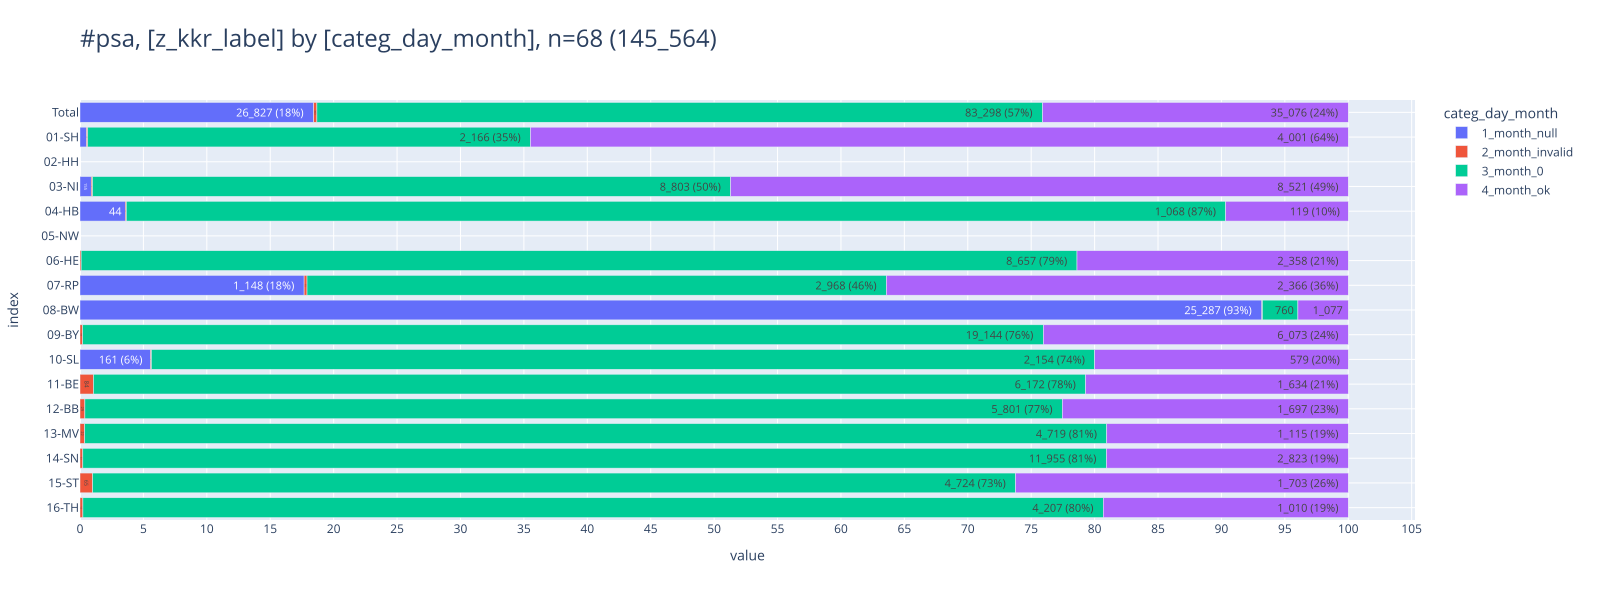

categ_day_month,1_month_null,2_month_invalid,3_month_0,4_month_ok,Total
z_kkr_label,,,,,
01-SH,32 (0.0%),6 (0.0%),2_166 (1.5%),4_001 (2.7%),6_205 (4.3%)
02-HH,0,0,0,0,0
03-NI,155 (0.1%),19 (0.0%),8_803 (6.0%),8_521 (5.9%),17_498 (12.0%)
04-HB,44 (0.0%),1 (0.0%),1_068 (0.7%),119 (0.1%),1_232 (0.8%)
05-NW,0,0,0,0,0
06-HE,0,10 (0.0%),8_657 (5.9%),2_358 (1.6%),11_025 (7.6%)
07-RP,1_148 (0.8%),15 (0.0%),2_968 (2.0%),2_366 (1.6%),6_497 (4.5%)
08-BW,25_287 (17.4%),11 (0.0%),760 (0.5%),1_077 (0.7%),27_135 (18.6%)
09-BY,0,54 (0.0%),19_144 (13.2%),6_073 (4.2%),25_271 (17.4%)


In [39]:
pls.plot_stacked_bars(
    db_psa.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="psa",
    height=600,
    width=1600,
    kkr_col="z_kkr_label",
)
tbl.pivot_df(db_psa.project("z_kkr_label,categ_day_month").to_df(), kkr_col="z_kkr_label")

In [40]:
if os.environ.get("DEBUG") == "1":
    db_psa_filter = db_psa.filter("left(categ_day_month,1) = '3'")
    display(db_psa_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

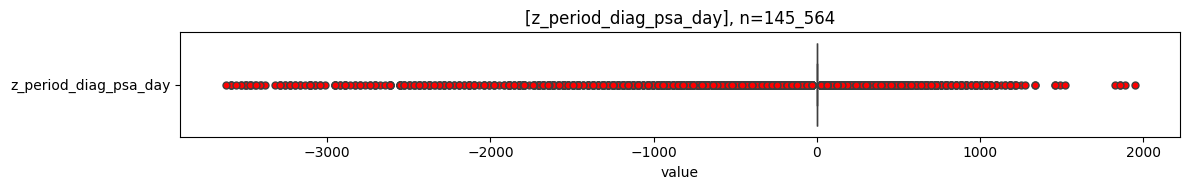


column (n = 145_564)  |    present    |  min   | lower |  q25  | median |  mean   |  q75  | upper |  max  |   std   |   cv   
----------------------+---------------+--------+-------+-------+--------+---------+-------+-------+-------+---------+--------
z_period_diag_psa_day | 118_374 (81%) | -3_623 |     0 | 0.000 |  0.000 | -11.248 | 0.000 |     0 | 1_947 | 134.060 | -11.919



In [41]:
pls.plot_box_large(db_psa.to_df().z_period_diag_psa_day)

## <a id='toc1_7_'></a>[Folgeereignis](#toc0_)
- Filter: keiner
- gezählt sind alle Folgeereignisse
- Kategorien für `categ_day_month` und deren mapping zur jeweiligen `z_` Variable (jede Kategorie impliziert, dass die vorherigen **nicht** zutreffen)
  - `1_month_null` - Datumsabstand NULL ➡️ NULL
  - `2_month_invalid` - Datumsabstand ungültig ➡️ NULL
  - `3_month_0` - Datumsabstand 0 ➡️ 0
  - `4_month_ok` - Datumsabstand valide ➡️ Datumsabstand

In [42]:
db_fo = con.sql(f"""--sql
    with t1 as (
        select
                tum.z_tum_id,
                z_kkr_label,
                Diagnosedatum,
                Diagnosedatum_Genauigkeit,
                ---
                Datum_Folgeereignis,
                Datum_Folgeereignis_Genauigkeit,
                datediff('day',
                    make_date(extract(year from Diagnosedatum), extract(month from Diagnosedatum), 15),
                    make_date(extract(year from Datum_Folgeereignis), extract(month from Datum_Folgeereignis), 15)
                )::int32 as period_month,
                CASE
                    WHEN period_month IS NULL
                    THEN '1_month_null'
                    WHEN    (
                                period_month not between 0 and {MAX_YEARS_TREAT*365}
                                or Datum_Folgeereignis_Genauigkeit IN ('M', 'V')
                                or Diagnosedatum_Genauigkeit IN ('M', 'V')
                            )
                    THEN '2_month_invalid'
                    WHEN
                        period_month = 0
                    THEN '3_month_0'
                    WHEN (
                            period_month between 0 and {MAX_YEARS_TREAT*365}
                            AND Datum_Folgeereignis_Genauigkeit NOT IN ('M', 'V')
                            AND Diagnosedatum_Genauigkeit NOT IN ('M', 'V')
                    ) 
                    then '4_month_ok'
                    ELSE '9_unknown'
                END AS categ_day_month,
        from Tumor tum
        join Folgeereignis fo on fo.z_tum_id=tum.z_tum_id
    ),
    t2 as (
        select  *,
                case
                    when categ_day_month = '1_month_null' then null
                    when categ_day_month = '2_month_invalid' then null
                    when categ_day_month = '3_month_0' then 0
                    when categ_day_month = '4_month_ok' then period_month
                    else null
                end as z_period_diag_fo_day
        from t1
    )
    select * from t2
""")
# db_fo

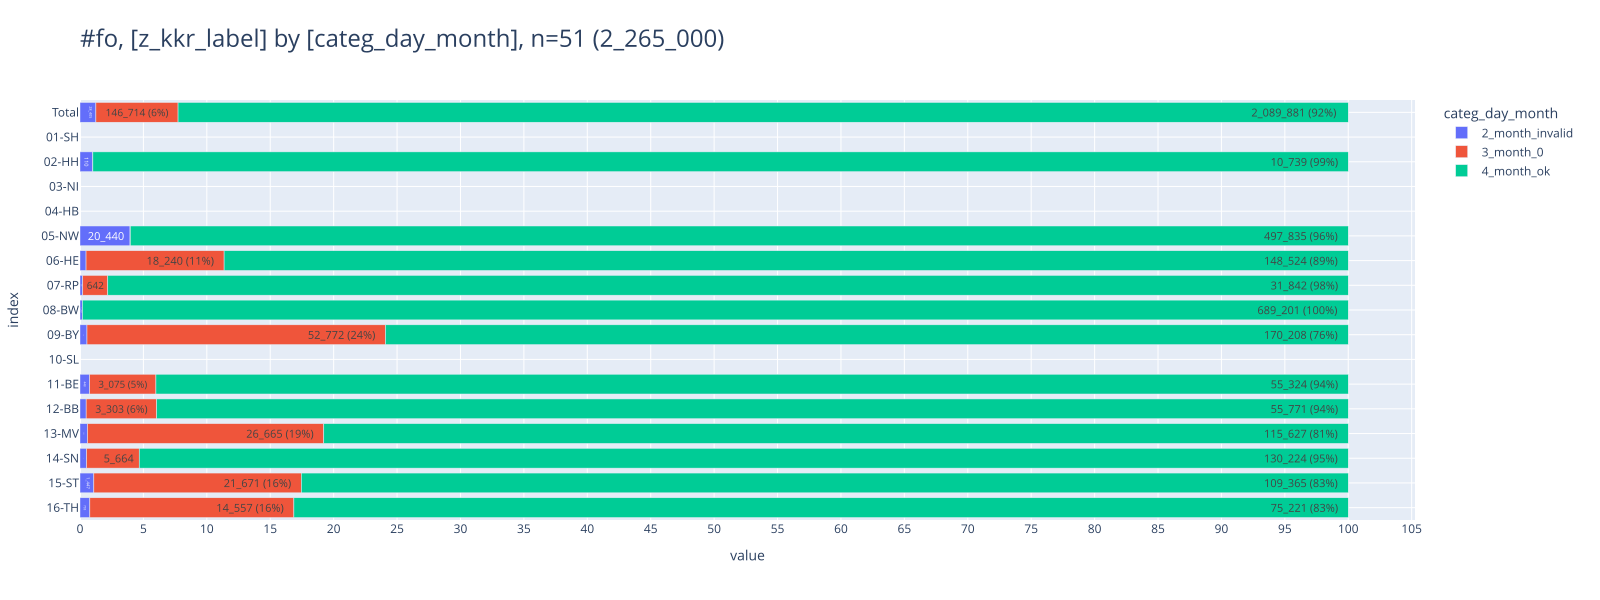

categ_day_month,2_month_invalid,3_month_0,4_month_ok,Total
z_kkr_label,,,,
01-SH,0,0,0,0
02-HH,110 (0.0%),0,10_739 (0.5%),10_849 (0.5%)
03-NI,0,0,0,0
04-HB,0,0,0,0
05-NW,20_440 (0.9%),120 (0.0%),497_835 (22.0%),518_395 (22.9%)
06-HE,800 (0.0%),18_240 (0.8%),148_524 (6.6%),167_564 (7.4%)
07-RP,71 (0.0%),642 (0.0%),31_842 (1.4%),32_555 (1.4%)
08-BW,1_297 (0.1%),5 (0.0%),689_201 (30.4%),690_503 (30.5%)
09-BY,1_236 (0.1%),52_772 (2.3%),170_208 (7.5%),224_216 (9.9%)


In [43]:
pls.plot_stacked_bars(
    db_fo.project("z_kkr_label,categ_day_month").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="fo",
    height=600,
    width=1600,
    kkr_col="z_kkr_label",
)
tbl.pivot_df(db_fo.project("z_kkr_label,categ_day_month").to_df(), kkr_col="z_kkr_label")

In [44]:
if os.environ.get("DEBUG") == "1":
    db_fo_filter = db_fo.filter("left(categ_day_month,1) = '2'")
    display(db_fo_filter)
    # hlp.get_tum_details("a2d3ecdd-4e0f-457c-ab5d-3949b2fb1e50", con)

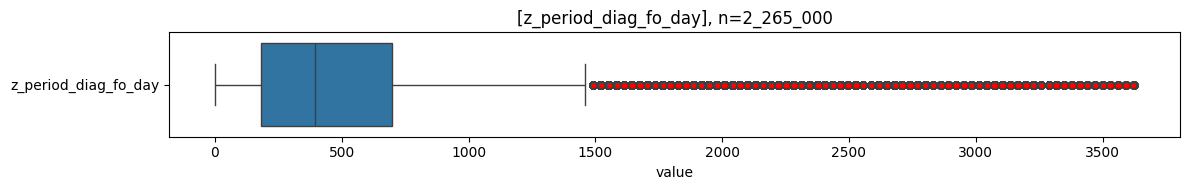


column (n = 2_265_000) |     present     | min | lower |   q25   | median  |  mean   |   q75   | upper |  max  |   std   |  cv  
-----------------------+-----------------+-----+-------+---------+---------+---------+---------+-------+-------+---------+------
z_period_diag_fo_day   | 2_236_595 (98%) |   0 |     0 | 183.000 | 393.000 | 480.916 | 700.000 | 1_461 | 3_624 | 399.063 | 0.830



In [45]:
pls.plot_box_large(db_fo.to_df().z_period_diag_fo_day)